# Iris Recognition — IrisIResNet50_MSFF + ArcFace (Production Refactor v7 — GradCAM/ONNX/AMP Fixes)
#
**Key changes over v3:**
1. Daugman Rubber Sheet Model replaces naive resize — only pure iris tissue is fed to the network
2. Input geometry changed from 224×224 to 64×512 (polar iris strip)
3. HoughCircles-based pupil/iris boundary localization
4. Backbone upgraded to IResNet50 with stride-1 first conv to preserve 64x512 resolution
5. Added Multi-Scale Feature Fusion (MSFF) combining Layer 3 and Layer 4 features
6. All other fixes from v3 retained (subject-exclusive split, ArcFace margin, etc.)

**v4.1 fixes (eye-cut corrected):**
- Reverted ArcFace margin `m` 0.50 → **0.25** (0.50 over-penalized this small subject-exclusive split — main cause of the EER regression)
- Daugman radial crop + hard eyelid mask kept, but **vectorized and CONFIG-driven** (`radial_inner/outer`, `mask_top_w/bottom_w/taper`)
- Rotation augmentation reduced so it no longer fights the fixed eyelid mask (`aug_roll_frac`)
- Added a **pre-training crop / eye-cut preview cell** (segmentation + polar + mask + back-projected kept wedges) so the crop can be verified before any training run
- Open-set eval now also reports **verification accuracy at the EER operating point** (the "random test" number)


### v5 patch summary
This version fixes the main thesis/protocol issues from the review:
- failed segmentations are filtered out instead of kept as zero images;
- train/validation/test are subject-exclusive;
- checkpoint selection uses open-set validation EER;
- train label names are saved after ArcFace class remapping;
- t-SNE uses the current scikit-learn `max_iter` argument;
- segmentation failure rate and confidence interval utilities are reported;
- ONNX/deployment documentation clarifies that preprocessing is outside the exported model;
- the fixed angular/wing mask is documented as a risky ablation, not an unquestioned assumption.


In [1]:
# Optional dependency install.
# Kaggle already has most packages; unconditional pip install can waste time and
# can also disturb CUDA/RAPIDS packages. Install only when an import is missing.
import importlib.util, subprocess, sys

_DEPS = [
    ("cv2", "opencv-python-headless"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("onnx", "onnx"),
    ("pytorch_grad_cam", "grad-cam"),
]

for import_name, package_name in _DEPS:
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"OK: {import_name}")


OK: cv2
OK: sklearn
OK: matplotlib
OK: onnx
Installing missing package: grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 21.6 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from math import pi
from contextlib import nullcontext

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
cudnn.deterministic = False
cudnn.benchmark = True  # Accelerate with optimal convolution algorithms
# Speed on Ampere/Ada/Hopper GPUs; harmless/no-op on T4.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

PyTorch: 2.10.0+cu128
Device: cuda


## Configuration

In [3]:
PLATFORM = "local"
if os.path.exists("/kaggle/input"):  PLATFORM = "kaggle"
elif os.path.exists("/content"):     PLATFORM = "colab"
print(f"Platform: {PLATFORM}")

if PLATFORM == "kaggle":
    _root = "/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand"
    _save = "/kaggle/working/iris_model_v5"
elif PLATFORM == "colab":
    _root = "/content/dataset/CASIA-Iris-Thousand/CASIA-Iris-Thousand"
    _save = "/content/drive/MyDrive/iris_model_v5"
else:
    _root = "./data/CASIA-Iris-Thousand"
    _save = "./checkpoints_v5"

CONFIG = {
    "dataset_root": _root,
    "save_dir": _save,
    "polar_height": 64,
    "polar_width": 512,
    "batch_size": 128,  # 128 is usually safe on T4x2/4090/A100 for 64x512 polar inputs
    "epochs": 40,  # quality run: previous best kept improving into the 30s
    "lr": 1e-3,
    "train_subject_frac": 0.70,
    "val_subject_frac": 0.10,
    "patience": 8,
    "min_samples": 3,
    "norm_mean": 0.449,
    "norm_std": 0.226,
    "arcface_s": 64.0,
    "arcface_m": 0.25,
    "dropout_rate": 0.35,

    # Radial crop
    "radial_inner": 0.10,
    "radial_outer": 0.87,

    # Soft angular mask
    "use_angular_mask": True,
    "angular_keep_frac": 0.60,
    "angular_mask_floor": 0.15,
    "angular_soft_edge": 24,

    # Randomized angular mask during training
    "randomize_angular_mask": True,
    "angular_keep_frac_min": 0.50,
    "angular_keep_frac_max": 0.75,

    # Speed / regularization
    "ido_center_search": 4,
    "preload_workers": 0,
    "aug_erase_prob": 0.15,
    "aug_roll_frac": 1/16,
    "bootstrap_resamples": 300,  # use 1000 only for final thesis numbers

    # Training speed / checkpointing
    "loader_workers": 0,          # keep 0 for Kaggle RAM cache stability; try 2 on rented GPU hosts
    "eval_every": 1,              # quality run: evaluate every epoch so we do not miss best checkpoint
    "eval_always_until_epoch": 10,
    "eval_always_last_epochs": 4,
    "val_n_pairs": 100_000,
    "test_n_pairs": 200_000,
    "impostor_multiplier": 5,     # more stable FAR threshold than 1:1 impostor sampling
    "target_far": 0.001,          # 0.1% FAR operating point
    "early_stop_min_delta": 0.02, # quality run: allow smaller but real EER improvements
    "weight_decay": 3e-4,
    "mask_bank_size": 32,
    "label_smoothing": 0.02,
    "freeze_warmup_epochs": 0,   # v6 used 5; this underfit/slowed convergence vs earlier better run
    "use_amp": True,             # mixed precision training/extraction on CUDA; speeds T4/4090/A100
}
os.makedirs(CONFIG["save_dir"], exist_ok=True)
assert os.path.isdir(CONFIG["dataset_root"]), f"Dataset not found: {CONFIG['dataset_root']}"
print(f"Dataset : {CONFIG['dataset_root']}")
print(f"Save dir: {CONFIG['save_dir']}")

Platform: kaggle
Dataset : /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand
Save dir: /kaggle/working/iris_model_v5


## Preprocessing: Daugman Rubber Sheet Model
#
Replaces the naive letterbox-resize with proper iris segmentation and polar unrolling:
1. **Pupil localization** via `cv2.HoughCircles` on blurred/thresholded image
2. **Iris localization** via `cv2.HoughCircles` on edge-detected image, constrained by pupil
3. **Rubber Sheet mapping**: for each (θ, r) in polar space, compute Cartesian coordinates
   using Daugman's model and sample with bilinear interpolation

In [4]:
def find_pupil_circle(gray):
    """Detect the pupillary boundary using HoughCircles on GRAYSCALE."""
    blurred = cv2.medianBlur(gray, 7)
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=100,
        param2=18,
        minRadius=15,
        maxRadius=80,
    )
    if circles is None:
        return None
    return circles[0][0]  # (x, y, r)


def _iris_arc_means(gray_f, cx, cy, radii, angles):
    """Median intensity along circles (cx,cy,r) over given angles — robust to lid/lash."""
    R = radii[:, None]; A = angles[None, :]
    map_x = (cx + R * np.cos(A)).astype(np.float32)
    map_y = (cy + R * np.sin(A)).astype(np.float32)
    samples = cv2.remap(gray_f, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return np.median(samples, axis=1)


def _valid_iris_geometry(gray, pupil_xyr, iris_xyr, min_ratio=1.8, max_ratio=5.0):
    """Reject implausible limbus estimates before unwrapping."""
    if pupil_xyr is None or iris_xyr is None:
        return False
    h, w = gray.shape
    px, py, pr = map(float, pupil_xyr)
    ix, iy, ir = map(float, iris_xyr)
    if pr <= 0 or ir <= 0:
        return False
    ratio = ir / pr
    if not (min_ratio <= ratio <= max_ratio):
        return False
    center_offset = np.hypot(px - ix, py - iy)
    if center_offset > 0.35 * ir:
        return False
    margin = 2
    if ix - ir < -margin or ix + ir >= w + margin or iy - ir < -margin or iy + ir >= h + margin:
        return False
    return True


def find_iris_boundary_ido(gray, pupil_xyr, r_lo=1.3, r_hi=5.0,
                           center_search=None, sigma=4.0, arc_deg=28, skip_inner=0.12):
    """
    Daugman-style integro-differential limbus search. It evaluates only the
    left/right arcs, where eyelid occlusion is usually lower, then chooses the
    radius with maximum smoothed radial derivative.
    """
    if center_search is None:
        center_search = int(CONFIG.get("ido_center_search", 4))
    px, py, pr = float(pupil_xyr[0]), float(pupil_xyr[1]), float(pupil_xyr[2])
    h, w = gray.shape
    gf = gray.astype(np.float32)
    angles = np.concatenate([np.linspace(-arc_deg, arc_deg, 50),
                             np.linspace(180 - arc_deg, 180 + arc_deg, 50)]) * (pi / 180.0)
    r_min = max(int(pr * r_lo), int(pr) + 5)
    r_max = min(int(pr * r_hi), int(0.97 * min(px, w - px, py, h - py)))
    if r_max <= r_min + 6:
        return None
    radii = np.arange(r_min, r_max, 1.0)
    k = max(3, int(sigma * 3) | 1)
    gk = cv2.getGaussianKernel(k, sigma).ravel()
    n_skip = max(2, int(len(radii) * skip_inner))
    best = (-1e9, None)
    for dy in range(-center_search, center_search + 1, 2):
        for dx in range(-center_search, center_search + 1, 2):
            cx, cy = px + dx, py + dy
            I_r = _iris_arc_means(gf, cx, cy, radii, angles)
            I_s = np.convolve(I_r, gk, mode="same")
            dI = np.gradient(I_s)
            dI[:n_skip] = 0.0; dI[-2:] = 0.0
            idx = int(np.argmax(dI))
            candidate = [cx, cy, int(round(float(radii[idx])))]
            if dI[idx] > best[0] and _valid_iris_geometry(gray, pupil_xyr, candidate):
                best = (float(dI[idx]), candidate)
    return best[1]


def _find_iris_hough(gray, pupil_xyr):
    """Fallback limbus finder via HoughCircles."""
    if pupil_xyr is None:
        return None
    px, py, pr = pupil_xyr
    blurred = cv2.medianBlur(gray, 7)
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=200,
        param1=100,
        param2=30,
        minRadius=int(pr * 1.5),
        maxRadius=int(pr * 4.0),
    )
    if circles is None:
        return None
    valid = []
    for c in circles[0]:
        if ((c[0]-px)**2 + (c[1]-py)**2) < pr**2 and c[2] > pr * 1.3:
            if _valid_iris_geometry(gray, pupil_xyr, c):
                valid.append(c)
    if not valid:
        return None
    return max(valid, key=lambda c: c[2])


def find_iris_circle(gray, pupil_xyr, return_method=False):
    """
    Localize the limbus. Returns None when detection is not reliable. This is
    intentional: failed segmentations are filtered, not silently converted into
    zero-valued training samples.
    """
    if pupil_xyr is None:
        return (None, "no_pupil") if return_method else None

    ido = find_iris_boundary_ido(gray, pupil_xyr)
    if _valid_iris_geometry(gray, pupil_xyr, ido):
        return (ido, "ido") if return_method else ido

    hough = _find_iris_hough(gray, pupil_xyr)
    if _valid_iris_geometry(gray, pupil_xyr, hough):
        return (hough, "hough") if return_method else hough

    # The old ratio fallback produced fake-looking successful segmentations.
    # For thesis-quality reporting, treat this as failure-to-enroll instead.
    return (None, "fail") if return_method else None


def daugman_rubber_sheet(gray, pupil_xyr, iris_xyr, polar_h=64, polar_w=512, r0=None, r1=None):
    """Unroll the iris annulus into a polar strip with the Daugman rubber-sheet model."""
    px, py, pr = pupil_xyr
    ix, iy, ir = iris_xyr
    if r0 is None: r0 = CONFIG["radial_inner"]
    if r1 is None: r1 = CONFIG["radial_outer"]

    theta = np.linspace(0, 2 * np.pi, polar_w, endpoint=False)
    px_c = px + pr * np.cos(theta); py_c = py + pr * np.sin(theta)
    ix_c = ix + ir * np.cos(theta); iy_c = iy + ir * np.sin(theta)

    radius = np.linspace(r0, r1, polar_h)[:, None]
    map_x = ((1 - radius) * px_c + radius * ix_c).astype(np.float32)
    map_y = ((1 - radius) * py_c + radius * iy_c).astype(np.float32)

    return cv2.remap(gray, map_x, map_y, interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REPLICATE)


# Track segmentation statistics globally; IrisDataset adds split-level detail.
_seg_stats = {"total": 0, "success": 0, "fail": 0, "methods": {}}

def preprocess_iris_to_polar(image_path, polar_h=64, polar_w=512, return_meta=False):
    """
    Load NIR image -> segment pupil & iris -> polar unroll.

    Returns:
      - polar uint8 array on success;
      - None on failure, so the Dataset can filter it out and report FTE/FTA.
    """
    meta = {"path": image_path, "ok": False, "reason": None, "method": None}
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        meta["reason"] = "read_fail"
        return (None, meta) if return_meta else None

    pupil = find_pupil_circle(img)
    if pupil is None:
        meta["reason"] = "pupil_fail"
        return (None, meta) if return_meta else None

    iris, method = find_iris_circle(img, pupil, return_method=True)
    if iris is None:
        meta["reason"] = method or "iris_fail"
        return (None, meta) if return_meta else None

    if not _valid_iris_geometry(img, pupil, iris):
        meta["reason"] = "invalid_geometry"
        return (None, meta) if return_meta else None

    polar = daugman_rubber_sheet(img, pupil, iris, polar_h, polar_w)
    if polar is None or polar.shape != (polar_h, polar_w) or not np.isfinite(polar).all():
        meta["reason"] = "unwrap_fail"
        return (None, meta) if return_meta else None

    meta.update({"ok": True, "reason": "ok", "method": method,
                 "pupil": tuple(map(float, pupil)), "iris": tuple(map(float, iris)),
                 "iris_pupil_ratio": float(iris[2] / pupil[2])})
    return (polar.astype(np.uint8), meta) if return_meta else polar.astype(np.uint8)

print("Daugman preprocessing defined — failures return None and are filtered/reported")
print(f"Polar output: {CONFIG['polar_height']}×{CONFIG['polar_width']}")

Daugman preprocessing defined — failures return None and are filtered/reported
Polar output: 64×512


## Dataset Class

## Why the fixed angular / “wing” mask is risky

The fixed angular mask is kept as a configurable ablation, not as a guaranteed improvement. It can help suppress common upper/lower eyelid regions in normalized polar coordinates, but it has important limitations:

1. It discards real iris texture, so the embedding may become less discriminative.
2. It assumes eyelids always occur at the same polar columns. Head tilt, eye torsion, off-center segmentation, or inconsistent unwrapping can shift the occlusion zones.
3. It conflicts with rotation augmentation: the iris strip can be rolled while the fixed mask remains stationary.
4. Hard mask boundaries can become artificial cues that the CNN learns instead of iris texture.
5. It is dataset- and acquisition-specific. It may work on controlled CASIA-style NIR images but generalize poorly to camera/Jetson deployment.

For thesis reporting, compare `use_angular_mask=True` against `use_angular_mask=False` and report open-validation/test EER for both. If the hard mask does not clearly improve subject-disjoint validation EER, remove it or replace it with an adaptive occlusion mask / second valid-mask channel.

In [5]:
def make_soft_angular_mask(
    polar_w=512,
    keep_frac=None,
    floor=None,
    soft_edge=None,
):
    if not CONFIG.get("use_angular_mask", True):
        return torch.ones(polar_w).float()

    keep_frac = CONFIG.get("angular_keep_frac", 0.60) if keep_frac is None else keep_frac
    floor = CONFIG.get("angular_mask_floor", 0.15) if floor is None else floor
    soft_edge = CONFIG.get("angular_soft_edge", 24) if soft_edge is None else soft_edge

    keep_frac = float(np.clip(keep_frac, 0.05, 1.00))
    floor = float(np.clip(floor, 0.00, 1.00))
    soft_edge = int(max(0, soft_edge))

    x = np.arange(polar_w, dtype=np.float32)
    centers = [0.0, polar_w / 2.0]

    total_keep = int(round(polar_w * keep_frac))
    side_keep = max(1, total_keep // 2)
    half_core = side_keep / 2.0

    mask = np.full(polar_w, floor, dtype=np.float32)

    for center in centers:
        # circular angular distance
        dist = np.abs(x - center)
        dist = np.minimum(dist, polar_w - dist)

        local = np.full(polar_w, floor, dtype=np.float32)

        # full-strength core
        core = dist <= half_core
        local[core] = 1.0

        # smooth taper
        if soft_edge > 0:
            edge = (dist > half_core) & (dist <= half_core + soft_edge)
            t = (dist[edge] - half_core) / float(soft_edge)
            local[edge] = floor + (1.0 - floor) * 0.5 * (1.0 + np.cos(np.pi * t))

        mask = np.maximum(mask, local)

    return torch.from_numpy(mask).float()


def make_training_angular_mask(polar_w=512):
    """
    During training, optionally randomize the fan width so the model does not
    overfit to one fixed eye aperture / eyelid shape.
    """
    if not CONFIG.get("use_angular_mask", True):
        return torch.ones(polar_w).float()

    if CONFIG.get("randomize_angular_mask", False):
        lo = CONFIG.get("angular_keep_frac_min", 0.50)
        hi = CONFIG.get("angular_keep_frac_max", 0.75)
        keep_frac = np.random.uniform(lo, hi)
    else:
        keep_frac = CONFIG.get("angular_keep_frac", 0.60)

    return make_soft_angular_mask(
        polar_w=polar_w,
        keep_frac=keep_frac,
        floor=CONFIG.get("angular_mask_floor", 0.15),
        soft_edge=CONFIG.get("angular_soft_edge", 24),
    )


# Backward-compatible name so old preview/evaluation cells still work.
def make_angular_mask(polar_w=512, top_w_f=None, bottom_w_f=None, taper_f=None):
    return make_soft_angular_mask(polar_w=polar_w)


class IrisDataset(Dataset):
    """
    Preloads polar iris images into RAM. Failed segmentations are removed, not
    converted into all-zero samples. This prevents contradictory labels from
    being attached to identical dummy inputs.
    """
    def __init__(self, image_paths, labels,
                 polar_h=64, polar_w=512, augment=False,
                 mean=0.449, std=0.226, split_name="split", skip_invalid=True):
        self.polar_h = polar_h
        self.polar_w = polar_w
        self.augment  = augment
        self.mean     = mean
        self.std      = std
        self.split_name = split_name

        # Validation/test use a fixed deterministic mask.
        # Training uses a small precomputed mask bank instead of constructing
        # a new NumPy/Torch mask for every sample. This saves CPU time.
        self.angular_mask = make_soft_angular_mask(polar_w).unsqueeze(0).unsqueeze(0)
        self.mask_bank = None
        if self.augment and CONFIG.get("use_angular_mask", True) and CONFIG.get("randomize_angular_mask", False):
            bank_size = int(CONFIG.get("mask_bank_size", 32))
            lo = CONFIG.get("angular_keep_frac_min", 0.50)
            hi = CONFIG.get("angular_keep_frac_max", 0.75)
            fracs = np.linspace(lo, hi, max(2, bank_size))
            self.mask_bank = torch.stack([
                make_soft_angular_mask(
                    polar_w=polar_w,
                    keep_frac=float(frac),
                    floor=CONFIG.get("angular_mask_floor", 0.15),
                    soft_edge=CONFIG.get("angular_soft_edge", 24),
                )
                for frac in fracs
            ], dim=0).unsqueeze(1).unsqueeze(1)  # [B,1,1,W]

        self.failed = []
        self.meta = []

        print(f"Preloading {len(image_paths)} images for {split_name} (polar {polar_h}×{polar_w})...")

        from concurrent.futures import ThreadPoolExecutor
        n_workers = CONFIG.get("preload_workers", 0) or min(8, (os.cpu_count() or 2) * 2)
        _prev_threads = cv2.getNumThreads()
        cv2.setNumThreads(1)

        _load = lambda p: preprocess_iris_to_polar(p, polar_h, polar_w, return_meta=True)

        try:
            with ThreadPoolExecutor(max_workers=n_workers) as ex:
                loaded = list(ex.map(_load, image_paths))
        except Exception as e:
            print(f"  parallel preload failed ({e}); falling back to sequential")
            loaded = [_load(p) for p in image_paths]
        finally:
            cv2.setNumThreads(_prev_threads)

        self.cache, self.labels, self.image_paths = [], [], []
        method_counts = {}

        for path, label, (polar, meta) in zip(image_paths, labels, loaded):
            if polar is None or not meta.get("ok", False):
                self.failed.append(meta)
                if not skip_invalid:
                    # Disabled by default. This branch is kept only for explicit failure-inclusion experiments.
                    self.cache.append(np.zeros((polar_h, polar_w), dtype=np.uint8))
                    self.labels.append(label)
                    self.image_paths.append(path)
                continue

            self.cache.append(polar)
            self.labels.append(label)
            self.image_paths.append(path)
            self.meta.append(meta)

            method = meta.get("method", "unknown")
            method_counts[method] = method_counts.get(method, 0) + 1

        n_total = len(image_paths)
        n_ok = len(self.cache)
        n_fail = n_total - n_ok

        _seg_stats["total"]   += n_total
        _seg_stats["success"] += n_ok
        _seg_stats["fail"]    += n_fail

        for k, v in method_counts.items():
            _seg_stats["methods"][k] = _seg_stats["methods"].get(k, 0) + v

        if n_ok == 0:
            raise RuntimeError(
                f"No valid iris segmentations for {split_name}. "
                "Check detection parameters and dataset path."
            )

        print(
            f"Preload complete ({n_workers} workers) — kept {n_ok}/{n_total}; "
            f"failed {n_fail} ({100*n_fail/max(1,n_total):.2f}%). "
            f"Methods: {method_counts}"
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.cache[idx].copy()
        label = self.labels[idx]

        if self.augment:
            img = self._augment(img)

        tensor = torch.from_numpy(img).float().unsqueeze(0) / 255.0
        tensor = (tensor - self.mean) / self.std

        if CONFIG.get("use_angular_mask", True):
            if self.augment and self.mask_bank is not None:
                # Fast randomized soft mask: choose from precomputed bank.
                mask_idx = np.random.randint(0, self.mask_bank.shape[0])
                tensor = tensor * self.mask_bank[mask_idx]
            else:
                # Fixed soft mask for validation/test.
                tensor = tensor * self.angular_mask

        return tensor, label

    def _augment(self, img):
        # Small torsion roll. Keep small because angular masks and large rolls can conflict.
        max_shift = max(1, int(CONFIG["polar_width"] * CONFIG.get("aug_roll_frac", 1/16)))
        shift = np.random.randint(-max_shift, max_shift + 1)
        img = np.roll(img, shift, axis=1)

        # Brightness/contrast jitter
        if np.random.rand() < 0.7:
            alpha = np.random.uniform(0.85, 1.15)
            beta  = np.random.uniform(-10, 10)
            img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

        # Random erasing / cutout
        if np.random.rand() < CONFIG.get("aug_erase_prob", 0.25):
            h, w = img.shape
            ew = np.random.randint(max(2, w // 32), max(3, w // 10))
            eh = np.random.randint(max(2, h // 10), max(3, h // 4))
            x0 = np.random.randint(0, max(1, w - ew))
            y0 = np.random.randint(0, max(1, h - eh))
            fill = int(np.median(img))
            img[y0:y0+eh, x0:x0+ew] = fill

        return img


print("IrisDataset defined — failed segmentations are filtered; soft angular mask enabled")

IrisDataset defined — failed segmentations are filtered; soft angular mask enabled


## Subject-Exclusive Data Split

In [6]:
from sklearn.model_selection import train_test_split as sk_split

EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def discover_casia(root, min_samples=3):
    all_paths, all_labels, label_names, subject_map = [], [], [], {}
    label_idx = 0

    for subj in sorted(os.listdir(root)):
        subj_dir = os.path.join(root, subj)
        if not os.path.isdir(subj_dir):
            continue
        for eye in ["L", "R"]:
            eye_dir = os.path.join(subj_dir, eye)
            if not os.path.isdir(eye_dir):
                continue
            images = [os.path.join(eye_dir, f)
                      for f in os.listdir(eye_dir)
                      if os.path.splitext(f)[1].lower() in EXTS]
            if len(images) >= min_samples:
                all_paths.extend(images)
                all_labels.extend([label_idx] * len(images))
                label_names.append(f"{subj}_{eye}")
                subject_map[label_idx] = subj
                label_idx += 1

    return all_paths, all_labels, label_names, subject_map

all_paths, all_labels, label_names, subject_map = discover_casia(
    CONFIG["dataset_root"], CONFIG["min_samples"]
)
NUM_CLASSES_TOTAL = len(label_names)
print(f"Total classes (subject+eye): {NUM_CLASSES_TOTAL}")
print(f"Total images: {len(all_paths)}")

Total classes (subject+eye): 2000
Total images: 20000


In [7]:
unique_subjects = sorted({subject_map[i] for i in range(NUM_CLASSES_TOTAL)})
rng = random.Random(SEED)
rng.shuffle(unique_subjects)

n_total = len(unique_subjects)
n_train = max(1, int(CONFIG["train_subject_frac"] * n_total))
n_val   = max(1, int(CONFIG["val_subject_frac"] * n_total))
if n_train + n_val >= n_total:
    n_val = max(1, n_total - n_train - 1)

train_subjects = set(unique_subjects[:n_train])
val_subjects   = set(unique_subjects[n_train:n_train + n_val])
test_subjects  = set(unique_subjects[n_train + n_val:])

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)
print(f"Train subjects      : {len(train_subjects)}")
print(f"Open-val subjects   : {len(val_subjects)}")
print(f"Held-out test subjects: {len(test_subjects)}")

# ArcFace head is trained only on training identities; validation/test labels stay raw for pair equality.
train_class_set       = {i for i in range(NUM_CLASSES_TOTAL) if subject_map[i] in train_subjects}
train_old_class_ids   = sorted(train_class_set)
train_class_remap     = {old: new for new, old in enumerate(train_old_class_ids)}
train_label_names     = [label_names[old] for old in train_old_class_ids]
NUM_CLASSES           = len(train_class_set)

train_paths  = [p for p, l in zip(all_paths, all_labels) if subject_map[l] in train_subjects]
train_labels = [train_class_remap[l] for p, l in zip(all_paths, all_labels) if subject_map[l] in train_subjects]

val_paths_raw  = [p for p, l in zip(all_paths, all_labels) if subject_map[l] in val_subjects]
val_labels_raw = [l for p, l in zip(all_paths, all_labels) if subject_map[l] in val_subjects]

test_paths_raw  = [p for p, l in zip(all_paths, all_labels) if subject_map[l] in test_subjects]
test_labels_raw = [l for p, l in zip(all_paths, all_labels) if subject_map[l] in test_subjects]

print(f"\nNUM_CLASSES (ArcFace training head): {NUM_CLASSES}")
print(f"Train images    : {len(train_paths):,}")
print(f"Open-val images : {len(val_paths_raw):,}")
print(f"Test images     : {len(test_paths_raw):,}")
print("Protocol: train, validation, and test identities are subject-disjoint.")

Train subjects      : 700
Open-val subjects   : 100
Held-out test subjects: 200

NUM_CLASSES (ArcFace training head): 1400
Train images    : 14,000
Open-val images : 2,000
Test images     : 4,000
Protocol: train, validation, and test identities are subject-disjoint.


In [8]:
# Reset segmentation stats before preloading
_seg_stats = {"total": 0, "success": 0, "fail": 0, "methods": {}}

train_ds = IrisDataset(train_paths, train_labels,
                       polar_h=CONFIG["polar_height"], polar_w=CONFIG["polar_width"],
                       augment=True, mean=CONFIG["norm_mean"], std=CONFIG["norm_std"],
                       split_name="train")
val_ds   = IrisDataset(val_paths_raw, val_labels_raw,
                       polar_h=CONFIG["polar_height"], polar_w=CONFIG["polar_width"],
                       augment=False, mean=CONFIG["norm_mean"], std=CONFIG["norm_std"],
                       split_name="open_val")
test_ds  = IrisDataset(test_paths_raw, test_labels_raw,
                       polar_h=CONFIG["polar_height"], polar_w=CONFIG["polar_width"],
                       augment=False, mean=CONFIG["norm_mean"], std=CONFIG["norm_std"],
                       split_name="test")

print(f"\nSegmentation stats — Total: {_seg_stats['total']}, "
      f"Success: {_seg_stats['success']}, Fail: {_seg_stats['fail']}")
if _seg_stats['total'] > 0:
    fail_rate = _seg_stats['fail'] / _seg_stats['total'] * 100
    print(f"Success rate: {_seg_stats['success']/_seg_stats['total']*100:.2f}%")
    print(f"Failure-to-enroll/acquire rate: {fail_rate:.2f}%")
    print(f"Segmentation methods: {_seg_stats.get('methods', {})}")

workers = int(CONFIG.get("loader_workers", 0))
_dl_kwargs = dict(num_workers=workers, pin_memory=torch.cuda.is_available())
if workers > 0:
    _dl_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          **_dl_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False,
                          **_dl_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False,
                          **_dl_kwargs)
print(f"DataLoaders ready — batch_size={CONFIG['batch_size']}, workers={workers}")

Preloading 14000 images for train (polar 64×512)...
Preload complete (8 workers) — kept 13741/14000; failed 259 (1.85%). Methods: {'ido': 13740, 'hough': 1}
Preloading 2000 images for open_val (polar 64×512)...
Preload complete (8 workers) — kept 1959/2000; failed 41 (2.05%). Methods: {'ido': 1959}
Preloading 4000 images for test (polar 64×512)...
Preload complete (8 workers) — kept 3942/4000; failed 58 (1.45%). Methods: {'ido': 3941, 'hough': 1}

Segmentation stats — Total: 20000, Success: 19642, Fail: 358
Success rate: 98.21%
Failure-to-enroll/acquire rate: 1.79%
Segmentation methods: {'ido': 19640, 'hough': 2}
DataLoaders ready — batch_size=128, workers=0


## Pre-Training Crop / Eye-Cut Preview

Verify the Daugman radial crop + eyelid mask land on real iris tissue **before** committing to a full training run. For each sample: detected pupil/iris boundaries, the full polar unroll, the radial-cropped strip, the angular mask, the final masked network input, and the kept region back-projected onto the eye (green = what the network actually sees).

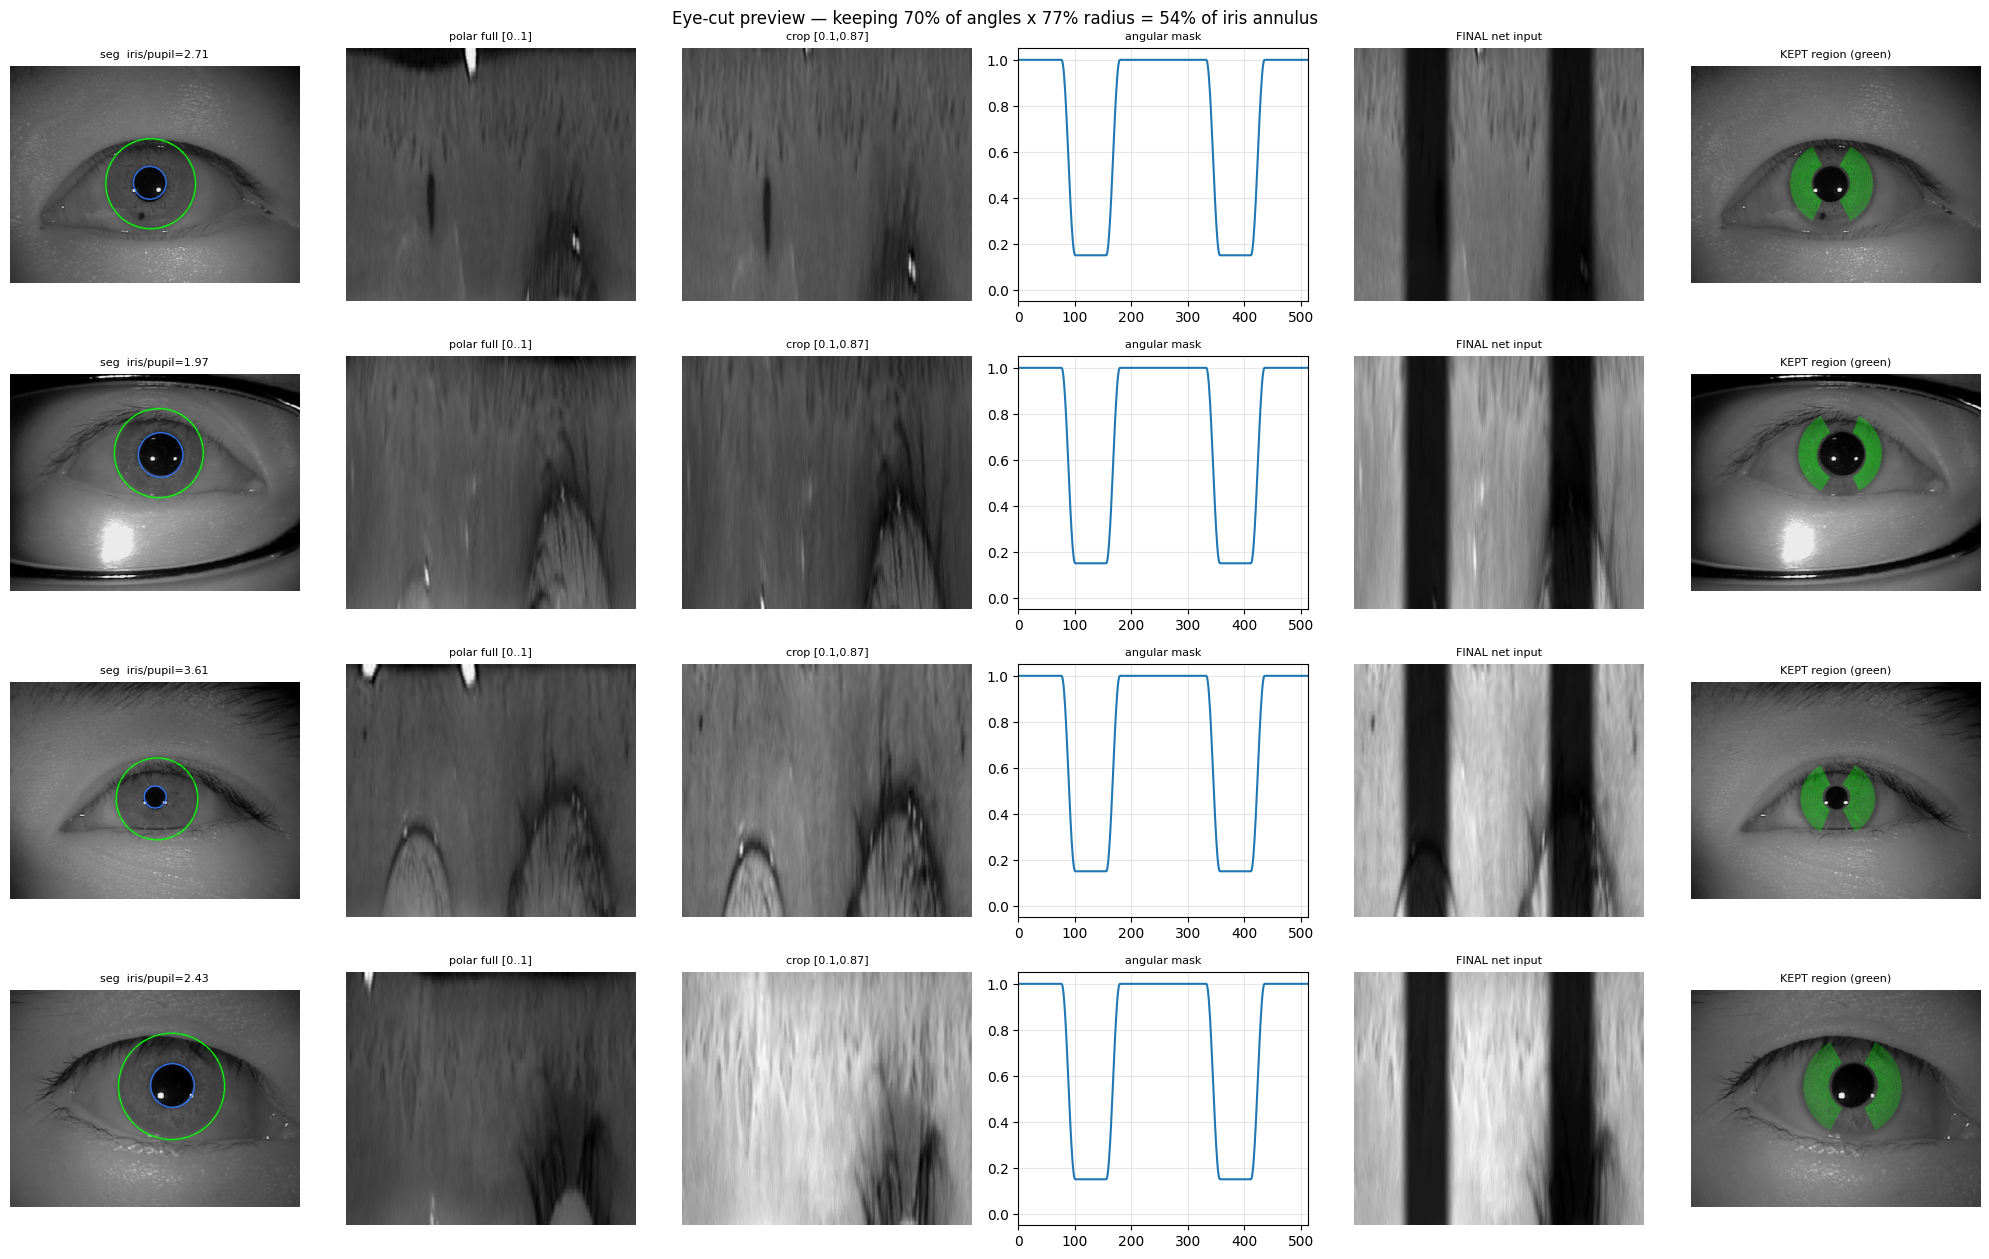

Segmentation OK on 200/200 sampled images (100%), mean iris/pupil ratio = 2.86.
Healthy iris/pupil is ~2.5-4.5. If the mean collapses to ~3.2 (the fallback) or the ratio is suspiciously tight, the IDO is failing on your data — widen arc_deg / r_hi.


In [9]:
# ── Pre-flight check: does the eye-cut land on real iris? (no trained model needed) ──
import matplotlib.pyplot as _plt

def _kept_overlay(gray, pupil, iris, mask_1d, r0, r1, n_r=40):
    """Back-project the kept columns (mask>0) onto the eye as a green overlay."""
    h, w = gray.shape
    px, py, pr = pupil; ix, iy, ir = iris
    pw = len(mask_1d)
    theta = np.linspace(0, 2 * pi, pw + 1)[:-1]
    rr = np.linspace(r0, r1, n_r)[:, None]
    pxc = px + pr * np.cos(theta); pyc = py + pr * np.sin(theta)
    ixc = ix + ir * np.cos(theta); iyc = iy + ir * np.sin(theta)
    X = (1 - rr) * pxc + rr * ixc
    Y = (1 - rr) * pyc + rr * iyc
    base  = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    layer = base.copy()
    keep_cols = np.where(mask_1d > 0.50)[0]
    for ti in keep_cols:
        xs = X[:, ti].astype(int); ys = Y[:, ti].astype(int)
        ok = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
        layer[ys[ok], xs[ok]] = (0, 255, 0)
    return cv2.addWeighted(base, 0.6, layer, 0.4, 0)

# Pull a handful of training images and run the real preprocessing functions on them
_n_prev = min(4, len(train_ds.image_paths))
_rng = np.random.default_rng(SEED)
_sample = _rng.choice(len(train_ds.image_paths), _n_prev, replace=False)

_mask_1d = make_angular_mask(CONFIG["polar_width"]).numpy()
_r0, _r1 = CONFIG["radial_inner"], CONFIG["radial_outer"]

fig, axes = _plt.subplots(_n_prev, 6, figsize=(20, 3.2 * _n_prev))
if _n_prev == 1: axes = axes[None, :]

for row, si in enumerate(_sample):
    path = train_ds.image_paths[si]
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    pupil = find_pupil_circle(gray)
    iris  = find_iris_circle(gray, pupil) if pupil is not None else None

    seg = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    ok = pupil is not None and iris is not None
    if ok:
        cv2.circle(seg, (int(pupil[0]), int(pupil[1])), int(pupil[2]), (50, 120, 255), 2)
        cv2.circle(seg, (int(iris[0]),  int(iris[1])),  int(iris[2]),  (0, 255, 0),  2)

    if ok:
        full = daugman_rubber_sheet(gray, pupil, iris, CONFIG["polar_height"], CONFIG["polar_width"], r0=1e-3, r1=1.0)
        crop = daugman_rubber_sheet(gray, pupil, iris, CONFIG["polar_height"], CONFIG["polar_width"], r0=_r0, r1=_r1)
        final = np.clip(crop.astype(np.float32) * _mask_1d[None, :], 0, 255).astype(np.uint8)
        kept  = _kept_overlay(gray, pupil, iris, _mask_1d, _r0, _r1)
        alpha = pupil[2] / iris[2]
    else:
        full = crop = final = np.zeros((CONFIG["polar_height"], CONFIG["polar_width"]), np.uint8)
        kept = seg; alpha = float("nan")

    axes[row, 0].imshow(seg); axes[row, 0].set_title((f"seg  iris/pupil={iris[2]/pupil[2]:.2f}" if ok else "SEG FAIL"), fontsize=8)
    axes[row, 1].imshow(full, cmap="gray", aspect="auto"); axes[row, 1].set_title("polar full [0..1]", fontsize=8)
    axes[row, 2].imshow(crop, cmap="gray", aspect="auto"); axes[row, 2].set_title(f"crop [{_r0},{_r1}]", fontsize=8)
    axes[row, 3].plot(_mask_1d); axes[row, 3].set_xlim(0, CONFIG["polar_width"]); axes[row, 3].set_ylim(-0.05, 1.05)
    axes[row, 3].set_title("angular mask", fontsize=8); axes[row, 3].grid(alpha=0.3)
    axes[row, 4].imshow(final, cmap="gray", aspect="auto"); axes[row, 4].set_title("FINAL net input", fontsize=8)
    axes[row, 5].imshow(kept); axes[row, 5].set_title("KEPT region (green)", fontsize=8)
    for c in (0, 1, 2, 4, 5): axes[row, c].axis("off")

_kept_frac = float((_mask_1d > 0.50).mean())
_keep_area = _kept_frac * (_r1 - _r0)
_plt.suptitle(f"Eye-cut preview — keeping {_kept_frac*100:.0f}% of angles x {(_r1-_r0)*100:.0f}% radius "
              f"= {_keep_area*100:.0f}% of iris annulus", fontsize=12)
_plt.tight_layout(); _plt.savefig(os.path.join(CONFIG["save_dir"], "crop_preview.png"), dpi=130); _plt.show()

# Quick segmentation reliability sample (does the crop even get valid boundaries?)
_chk = _rng.choice(len(train_ds.image_paths), min(200, len(train_ds.image_paths)), replace=False)
_succ, _ratios = 0, []
for si in _chk:
    g = cv2.imread(train_ds.image_paths[si], cv2.IMREAD_GRAYSCALE)
    p = find_pupil_circle(g)
    if p is None: continue
    ir = find_iris_circle(g, p)
    if ir is None: continue
    ratio = ir[2] / p[2]
    if 1.8 <= ratio <= 5.0:
        _succ += 1; _ratios.append(ratio)
_mr = np.mean(_ratios) if _ratios else float("nan")
print(f"Segmentation OK on {_succ}/{len(_chk)} sampled images ({100*_succ/len(_chk):.0f}%), "
      f"mean iris/pupil ratio = {_mr:.2f}.")
print("Healthy iris/pupil is ~2.5-4.5. If the mean collapses to ~3.2 (the fallback) or the "
      "ratio is suspiciously tight, the IDO is failing on your data — widen arc_deg / r_hi.")


## Model: IrisIResNet50_MSFF + ArcFace
#
IResNet50 customized for 1-channel 64×512 polar iris input with MSFF.
No maxpool, stride-1 conv1 preserves spatial resolution.
Feature map sizes through the network:
- conv1 (stride 1): 64×512
- layer1 (stride 2): 32×256, layer2 (stride 2): 16×128
- layer3 (stride 2): 8×64 (256ch), layer4 (stride 2): 4×32 (512ch)
- MSFF fuses L3↓(256ch) + L4(512ch) = 768ch × 4×32 = 98,304 → FC → 512

In [10]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)

def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class IBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None,
                 groups=1, base_width=64, dilation=1):
        super(IBasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-05)
        self.conv1 = conv3x3(inplanes, planes)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-05)
        self.prelu = nn.PReLU(planes)
        self.conv2 = conv3x3(planes, planes, stride)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-05)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out

class IrisIResNet50_MSFF(nn.Module):
    """
    IResNet50 backbone customized for 1-channel polar iris strips (64x512)
    with Multi-Scale Feature Fusion (MSFF) combining Layer3 and Layer4.
    AdaptiveAvgPool2d compresses spatial dims before FC to prevent overfitting.
    """
    fc_scale = 4 * 8  # After AdaptiveAvgPool2d((4, 8))
    def __init__(self, num_features=512):
        super().__init__()
        self.inplanes = 64
        self.dilation = 1
        self.groups = 1
        self.base_width = 64
        block = IBasicBlock
        layers = [3, 4, 14, 3]  # IResNet50 layers

        # 1-channel conv1 for grayscale iris strips
        self.conv1 = nn.Conv2d(1, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.inplanes, eps=1e-05)
        self.prelu = nn.PReLU(self.inplanes)
        
        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.bn2 = nn.BatchNorm2d(512 * block.expansion, eps=1e-05)
        
        # Multi-Scale Feature Fusion (MSFF) blocks
        # Downsample Layer3 (256x8x64) -> (256x4x32) to match Layer4
        self.fusion_conv = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.fusion_bn = nn.BatchNorm2d(256, eps=1e-05)
        self.fusion_prelu = nn.PReLU(256)
        
        # Spatial compression: 4x32 -> 4x8 to prevent FC bloat
        self.pool = nn.AdaptiveAvgPool2d((4, 8))
        
        # Fused channels: 256 (from L3) + 512 (from L4) = 768
        # After pooling: 768 x 4 x 8 = 24,576 (vs 98,304 without pooling)
        self.dropout = nn.Dropout(p=CONFIG["dropout_rate"])
        self.fc = nn.Linear(768 * block.expansion * self.fc_scale, num_features)
        
        self.features = nn.BatchNorm1d(num_features, eps=1e-05)
        nn.init.constant_(self.features.weight, 1.0)
        self.features.weight.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0, 0.1)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion, eps=1e-05),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups, self.base_width, self.dilation))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups, base_width=self.base_width, dilation=self.dilation))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        
        l3_feat = self.layer3(x)  # 256 x 8 x 64
        
        l4_feat = self.layer4(l3_feat)  # 512 x 4 x 32
        x = self.bn2(l4_feat)
        
        # MSFF: process l3_feat to match l4_feat spatial dimensions
        l3_down = self.fusion_conv(l3_feat)
        l3_down = self.fusion_bn(l3_down)
        l3_down = self.fusion_prelu(l3_down)  # 256 x 4 x 32
        
        # Concatenate along channel dim: (256 + 512 = 768) x 4 x 32
        fused = torch.cat((l3_down, x), dim=1)
        fused = self.pool(fused)  # 768 x 4 x 32 -> 768 x 4 x 8
        fused = torch.flatten(fused, 1)
        
        fused = self.dropout(fused)
        x = self.fc(fused)
        x = self.features(x)
        
        embeds = F.normalize(x, p=2, dim=1)
        return embeds, l3_feat, l4_feat

    def get_embedding(self, x):
        embeds, _, _ = self.forward(x)
        return embeds


class ArcFaceHead(nn.Module):
    """Additive Angular Margin (ArcFace) classification head."""
    def __init__(self, embedding_dim, num_classes, s=64.0, m=0.50):
        super().__init__()
        self.s   = s
        self.m   = m
        self.num_classes = num_classes
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        W      = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(embeddings, W)
        theta  = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        target = torch.cos(theta + self.m)
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        output  = cosine * (1 - one_hot) + target * one_hot
        return output * self.s

    def get_cosine(self, embeddings):
        W = F.normalize(self.weight, p=2, dim=1)
        return F.linear(embeddings, W)


model       = IrisIResNet50_MSFF().to(DEVICE)
arcface     = ArcFaceHead(512, NUM_CLASSES,
                          s=CONFIG["arcface_s"], m=CONFIG["arcface_m"]).to(DEVICE)
base_model  = model

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
    base_model = model.module

n_backbone = sum(p.numel() for p in base_model.parameters())
n_head     = sum(p.numel() for p in arcface.parameters())
print(f"IrisIResNet50_MSFF: {n_backbone:,} params")
print(f"ArcFace head: {n_head:,} params  (s={arcface.s}, m={arcface.m}, classes={NUM_CLASSES})")

# Verify feature map sizes
with torch.no_grad():
    _dummy = torch.randn(2, 1, CONFIG["polar_height"], CONFIG["polar_width"]).to(DEVICE)
    _, _l3, _l4 = base_model(_dummy)
    print(f"Layer3 feature map: {_l3.shape}")
    print(f"Layer4 feature map: {_l4.shape}")

IrisIResNet50_MSFF: 43,918,144 params
ArcFace head: 716,800 params  (s=64.0, m=0.25, classes=1400)
Layer3 feature map: torch.Size([2, 256, 8, 64])
Layer4 feature map: torch.Size([2, 512, 4, 32])


## Attention Penalty (Removed)
#
Spatial regularization is no longer needed since Daugman Rubber Sheet model
fundamentally isolates the pure iris tissue, removing the background.
Additionally, MSFF (Multi-Scale Feature Fusion) now handles multi-scale features
much better than attention over single-layer spatial maps.

In [11]:
# (Attention logic removed in v4 to accommodate MSFF)

## Training Loop

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG.get("label_smoothing", 0.02))

# Mixed precision helper. This uses AMP on CUDA and safely falls back on CPU/older PyTorch.
USE_AMP = bool(CONFIG.get("use_amp", True) and DEVICE.type == "cuda")

def autocast_ctx():
    if not USE_AMP:
        return nullcontext()
    try:
        return torch.amp.autocast("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.autocast(enabled=True)

def make_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

print(f"AMP mixed precision: {'ON' if USE_AMP else 'OFF'}")


def extract_embeddings(loader, model, device):
    embeds_list, labels_list = [], []
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device, non_blocking=True)
            with autocast_ctx():
                emb, _, _ = model(imgs)
            embeds_list.append(emb.float().cpu().numpy())
            labels_list.append(lbls.numpy())
    return np.concatenate(embeds_list), np.concatenate(labels_list)


def _threshold_for_far(fpr, tpr, thr, target_far=0.001):
    """Choose the finite threshold with max TAR while FPR <= target FAR."""
    fpr = np.asarray(fpr); tpr = np.asarray(tpr); thr = np.asarray(thr)
    valid = np.where((fpr <= target_far) & np.isfinite(thr))[0]
    if len(valid) == 0:
        # Fall back to the strictest finite threshold.
        finite = np.where(np.isfinite(thr))[0]
        idx = int(finite[0]) if len(finite) else 0
    else:
        # Among thresholds satisfying FAR, choose highest TAR.
        idx = int(valid[np.argmax(tpr[valid])])
    return float(thr[idx]), float(tpr[idx]), float(fpr[idx])


def compute_eer_auc(embeds, labels, n_pairs=100_000, seed=0,
                    target_far=None, impostor_multiplier=None):
    """Pair-sampled open-set verification metrics using cosine similarity.

    Important v6 change:
    - EER threshold and low-FAR deployment threshold are separated.
    - Impostor pairs are oversampled for more stable FAR@0.1% estimation.
    """
    if target_far is None:
        target_far = CONFIG.get("target_far", 0.001)
    if impostor_multiplier is None:
        impostor_multiplier = CONFIG.get("impostor_multiplier", 5)

    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    embeds = np.asarray(embeds)
    N = len(embeds)
    idx_all = np.arange(N)

    genuine_pairs = []
    for lbl in np.unique(labels):
        idxs = idx_all[labels == lbl]
        if len(idxs) < 2:
            continue
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                genuine_pairs.append((idxs[i], idxs[j]))

    # Reserve room for more impostors; genuine pairs are usually much fewer.
    if n_pairs is not None:
        max_genuine = max(1, n_pairs // (1 + int(impostor_multiplier)))
        if len(genuine_pairs) > max_genuine:
            keep = rng.choice(len(genuine_pairs), size=max_genuine, replace=False)
            genuine_pairs = [genuine_pairs[i] for i in keep]

    n_genuine = len(genuine_pairs)
    if n_pairs is None:
        target_impostors = max(n_genuine, n_genuine * int(impostor_multiplier))
    else:
        target_impostors = max(1, min(n_pairs - n_genuine, n_genuine * int(impostor_multiplier)))

    impostor_pairs = []
    attempts = 0
    while len(impostor_pairs) < target_impostors and attempts < 50:
        need = max(1024, (target_impostors - len(impostor_pairs)) * 2)
        a = rng.integers(0, N, size=need)
        b = rng.integers(0, N, size=need)
        mask = labels[a] != labels[b]
        impostor_pairs.extend(list(zip(a[mask], b[mask])))
        attempts += 1
    impostor_pairs = impostor_pairs[:target_impostors]

    if len(genuine_pairs) == 0 or len(impostor_pairs) == 0:
        return {"eer": 50.0, "auc": 0.5, "tar_at_01far": 0.0, "acc_eer": 50.0,
                "threshold": 1.0, "threshold_far": 1.0, "actual_far": 0.0,
                "fpr": np.array([0.0, 1.0]), "tpr": np.array([0.0, 1.0]),
                "scores": np.array([]), "is_genuine": np.array([]),
                "n_genuine_pairs": len(genuine_pairs), "n_impostor_pairs": len(impostor_pairs)}

    all_pairs = genuine_pairs + impostor_pairs
    is_genuine = np.array([1] * len(genuine_pairs) + [0] * len(impostor_pairs))
    a_idx = np.array([p[0] for p in all_pairs])
    b_idx = np.array([p[1] for p in all_pairs])
    scores = (embeds[a_idx] * embeds[b_idx]).sum(axis=1)

    fpr, tpr, thr = roc_curve(is_genuine, scores)
    roc_auc = auc(fpr, tpr)

    fnr = 1 - tpr
    eer_idx = int(np.argmin(np.abs(fpr - fnr)))
    eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2 * 100)
    threshold_eer = float(thr[eer_idx]) if np.isfinite(thr[eer_idx]) else float(np.max(scores) + 1e-6)

    threshold_far, tar_at_far, actual_far = _threshold_for_far(fpr, tpr, thr, target_far=target_far)

    preds = (scores >= threshold_eer).astype(int)
    acc_eer = float((preds == is_genuine).mean()) * 100

    return {"eer": eer, "auc": float(roc_auc), "tar_at_01far": tar_at_far, "acc_eer": acc_eer,
            "threshold": threshold_eer, "threshold_far": threshold_far, "actual_far": actual_far,
            "fpr": fpr, "tpr": tpr, "scores": scores, "is_genuine": is_genuine,
            "n_genuine_pairs": len(genuine_pairs), "n_impostor_pairs": len(impostor_pairs)}


def bootstrap_metric_ci(scores, is_genuine, n_resamples=1000, seed=0):
    """Bootstrap CIs for EER and AUC from already-generated verification pairs."""
    scores = np.asarray(scores)
    is_genuine = np.asarray(is_genuine)
    if len(scores) == 0 or int(n_resamples) <= 0:
        return {"eer_ci95": (np.nan, np.nan), "auc_ci95": (np.nan, np.nan)}
    rng = np.random.default_rng(seed)
    eers, aucs = [], []
    n = len(scores)
    for _ in range(int(n_resamples)):
        idx = rng.integers(0, n, size=n)
        y = is_genuine[idx]
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, scores[idx])
        fnr = 1 - tpr
        eer_idx = int(np.argmin(np.abs(fpr - fnr)))
        eers.append((fpr[eer_idx] + fnr[eer_idx]) / 2 * 100)
        aucs.append(auc(fpr, tpr))
    return {"eer_ci95": tuple(np.percentile(eers, [2.5, 97.5])) if eers else (np.nan, np.nan),
            "auc_ci95": tuple(np.percentile(aucs, [2.5, 97.5])) if aucs else (np.nan, np.nan)}


# Optional warmup freeze. Earlier speed v6 used 5 epochs, but that caused underfitting
# compared with the stronger previous run. Default is 0 = train end-to-end immediately.
freeze_warmup_epochs = int(CONFIG.get("freeze_warmup_epochs", 0))
if freeze_warmup_epochs > 0:
    print(f"Freezing backbone for {freeze_warmup_epochs}-epoch warmup...")
    for name, param in base_model.named_parameters():
        if not any(x in name for x in ["fc", "features", "fusion_conv", "fusion_bn", "fusion_prelu"]):
            param.requires_grad = False
else:
    print("No backbone freeze warmup — training end-to-end from epoch 1.")

optimizer = optim.AdamW(
    [{"params": [p for p in model.parameters() if p.requires_grad]},
     {"params": [p for p in arcface.parameters() if p.requires_grad]}],
    lr=CONFIG["lr"], weight_decay=CONFIG.get("weight_decay", 3e-4)
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, CONFIG['epochs'] - freeze_warmup_epochs),
    eta_min=1e-6
)
history = {"train_loss": [], "train_acc": [], "val_eer": [], "val_auc": [], "val_tar_at_01far": []}
best_val_eer = float("inf")
best_val_threshold = None
best_val_threshold_far = None
best_val_tar_far = -1.0
patience_ctr = 0
last_val_metrics = None
scaler = make_grad_scaler()

for epoch in range(CONFIG["epochs"]):
    if freeze_warmup_epochs > 0 and epoch == freeze_warmup_epochs:
        print("Unfreezing backbone for end-to-end fine-tuning...")
        for param in base_model.parameters():
            param.requires_grad = True
        base_model.features.weight.requires_grad = False
        optimizer = optim.AdamW(
            [{"params": [p for p in model.parameters() if p.requires_grad]},
             {"params": [p for p in arcface.parameters() if p.requires_grad]}],
            lr=CONFIG["lr"] * 0.1, weight_decay=CONFIG.get("weight_decay", 3e-4)
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, CONFIG['epochs'] - freeze_warmup_epochs), eta_min=1e-6
        )

    model.train(); arcface.train()
    run_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        lbls = lbls.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast_ctx():
            embeds, _, _ = model(imgs)
            logits = arcface(embeds, lbls)
            loss = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(arcface.parameters()), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        run_loss += loss.item() * imgs.size(0)
        # Faster approximate train accuracy: use already-computed ArcFace logits.
        # Closed-set train accuracy is only a diagnostic; open-set EER is the real metric.
        correct += (logits.detach().argmax(1) == lbls).sum().item()
        total += lbls.size(0)

    train_loss = run_loss / max(1, total)
    train_acc = correct / max(1, total)

    # Subject-disjoint open-set validation. To save time, evaluate every N epochs
    # after early training, and always during the final few epochs.
    eval_every = int(CONFIG.get("eval_every", 1))
    always_until = int(CONFIG.get("eval_always_until_epoch", 10))
    always_last = int(CONFIG.get("eval_always_last_epochs", 4))
    should_eval = (
        epoch < always_until or
        epoch >= CONFIG["epochs"] - always_last or
        ((epoch + 1) % max(1, eval_every) == 0) or
        last_val_metrics is None
    )

    if should_eval:
        val_embeds, val_labels_arr = extract_embeddings(val_loader, base_model, DEVICE)
        val_metrics = compute_eer_auc(
            val_embeds, val_labels_arr,
            n_pairs=CONFIG.get("val_n_pairs", 50_000),
            seed=SEED + epoch,
            target_far=CONFIG.get("target_far", 0.001),
            impostor_multiplier=CONFIG.get("impostor_multiplier", 5),
        )
        last_val_metrics = val_metrics
    else:
        val_metrics = last_val_metrics

    if epoch >= freeze_warmup_epochs:
        scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_eer"].append(val_metrics["eer"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_tar_at_01far"].append(val_metrics["tar_at_01far"])

    lr_now = optimizer.param_groups[0]["lr"]
    eval_tag = "" if should_eval else " (reused)"
    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
          f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
          f"Open-Val EER {val_metrics['eer']:.3f}%{eval_tag} AUC {val_metrics['auc']:.4f} "
          f"TAR@0.1%FAR {val_metrics['tar_at_01far']*100:.2f}% | LR {lr_now:.6f}")

    # Save every numerical best EER, but only reset patience when the improvement is meaningful.
    improved_any = val_metrics["eer"] < best_val_eer
    improved_meaningful = val_metrics["eer"] < (best_val_eer - CONFIG.get("early_stop_min_delta", 0.0))
    if improved_any:
        best_val_eer = val_metrics["eer"]
        best_val_threshold = val_metrics["threshold"]
        best_val_threshold_far = val_metrics["threshold_far"]
        torch.save({
            "model_state_dict":   base_model.state_dict(),
            "arcface_state_dict": arcface.state_dict(),
            "num_classes":        NUM_CLASSES,
            "label_names":        train_label_names,
            "old_class_ids":      train_old_class_ids,
            "train_class_remap":  train_class_remap,
            "epoch":              epoch,
            "val_eer":            best_val_eer,
            "val_threshold":      best_val_threshold,      # EER threshold, diagnostic only
            "val_threshold_far":  best_val_threshold_far,  # deployment threshold for target FAR
            "target_far":         CONFIG.get("target_far", 0.001),
            "val_tar_at_target_far": val_metrics["tar_at_01far"],
            "val_actual_far":     val_metrics.get("actual_far", float("nan")),
            "val_auc":            val_metrics["auc"],
            "config":             CONFIG,
        }, os.path.join(CONFIG["save_dir"], "best_model.pth"))
        print(f"  → Saved best EER model (open-val EER={best_val_eer:.3f}%, "
              f"EER-thr={best_val_threshold:.4f}, FAR-thr={best_val_threshold_far:.4f})")

    # Also save the checkpoint that is best specifically at TAR@0.1%FAR.
    if val_metrics["tar_at_01far"] > best_val_tar_far:
        best_val_tar_far = val_metrics["tar_at_01far"]
        torch.save({
            "model_state_dict":   base_model.state_dict(),
            "arcface_state_dict": arcface.state_dict(),
            "num_classes":        NUM_CLASSES,
            "label_names":        train_label_names,
            "old_class_ids":      train_old_class_ids,
            "train_class_remap":  train_class_remap,
            "epoch":              epoch,
            "val_eer":            val_metrics["eer"],
            "val_threshold":      val_metrics["threshold"],
            "val_threshold_far":  val_metrics["threshold_far"],
            "target_far":         CONFIG.get("target_far", 0.001),
            "val_tar_at_target_far": val_metrics["tar_at_01far"],
            "val_actual_far":     val_metrics.get("actual_far", float("nan")),
            "val_auc":            val_metrics["auc"],
            "config":             CONFIG,
        }, os.path.join(CONFIG["save_dir"], "best_model_by_tar001.pth"))
        print(f"  → Saved best TAR@0.1%FAR model (TAR={best_val_tar_far*100:.2f}%, "
              f"FAR-thr={val_metrics['threshold_far']:.4f})")

    if should_eval:
        if improved_meaningful:
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= CONFIG["patience"]:
                print(f"  → Early stopping at epoch {epoch+1}")
                break

print(f"\nTraining complete. Best open-val EER: {best_val_eer:.3f}%")
print(f"Best EER-threshold: {best_val_threshold:.4f}; deployment FAR-threshold: {best_val_threshold_far:.4f}")


AMP mixed precision: ON
Freezing backbone for 5-epoch warmup...
Epoch 01/36 | Train Loss 22.0377 Acc 0.0000 | Open-Val EER 24.973% AUC 0.8300 TAR@0.1%FAR 10.97% | LR 0.001000
  → Saved best EER model (open-val EER=24.973%, EER-thr=0.4355, FAR-thr=0.9586)
  → Saved best TAR@0.1%FAR model (TAR=10.97%, FAR-thr=0.9586)
Epoch 02/36 | Train Loss 19.4651 Acc 0.0000 | Open-Val EER 17.516% AUC 0.9016 TAR@0.1%FAR 23.36% | LR 0.001000
  → Saved best EER model (open-val EER=17.516%, EER-thr=0.3249, FAR-thr=0.8159)
  → Saved best TAR@0.1%FAR model (TAR=23.36%, FAR-thr=0.8159)
Epoch 03/36 | Train Loss 17.2738 Acc 0.0006 | Open-Val EER 13.537% AUC 0.9352 TAR@0.1%FAR 32.79% | LR 0.001000
  → Saved best EER model (open-val EER=13.537%, EER-thr=0.2657, FAR-thr=0.6868)
  → Saved best TAR@0.1%FAR model (TAR=32.79%, FAR-thr=0.6868)
Epoch 04/36 | Train Loss 15.0635 Acc 0.0042 | Open-Val EER 11.774% AUC 0.9467 TAR@0.1%FAR 38.41% | LR 0.001000
  → Saved best EER model (open-val EER=11.774%, EER-thr=0.2353, FA

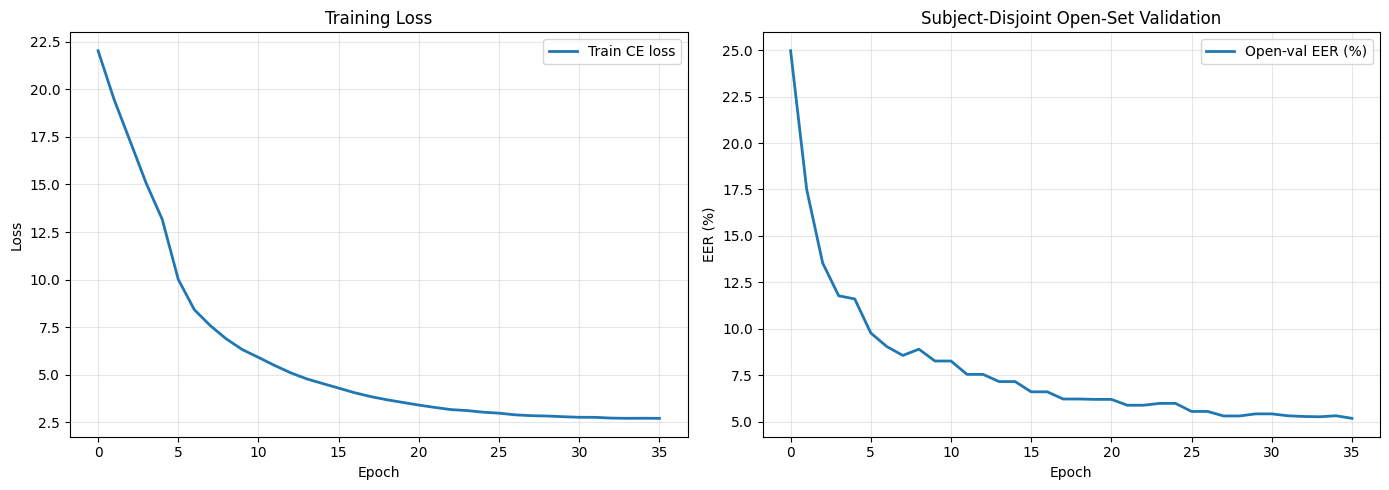

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="Train CE loss", lw=2)
ax1.set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history["val_eer"], label="Open-val EER (%)", lw=2)
ax2.set(xlabel="Epoch", ylabel="EER (%)", title="Subject-Disjoint Open-Set Validation")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "training_curves_openset.png"), dpi=150)
plt.show()

## Open-Set Evaluation: EER, TAR@FAR, AUC

In [14]:
ckpt = torch.load(os.path.join(CONFIG["save_dir"], "best_model.pth"),
                  map_location=DEVICE, weights_only=False)
base_model.load_state_dict(ckpt["model_state_dict"])
arcface.load_state_dict(ckpt["arcface_state_dict"])
base_model.eval(); arcface.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']+1}")
print(f"Checkpoint selected by open-val EER: {ckpt.get('val_eer', float('nan')):.3f}%")
print(f"Open-val EER threshold saved: {ckpt.get('val_threshold', float('nan')):.4f}")
print(f"Open-val target-FAR threshold saved for deployment: {ckpt.get('val_threshold_far', float('nan')):.4f}")

print("Extracting test embeddings...")
test_embeds, test_labels_arr = extract_embeddings(test_loader, base_model, DEVICE)
print(f"Embeddings: {test_embeds.shape}")

metrics = compute_eer_auc(
    test_embeds, test_labels_arr,
    n_pairs=CONFIG.get("test_n_pairs", 100_000),
    seed=SEED,
    target_far=CONFIG.get("target_far", 0.001),
    impostor_multiplier=CONFIG.get("impostor_multiplier", 5),
)
ci = bootstrap_metric_ci(metrics["scores"], metrics["is_genuine"],
                         n_resamples=CONFIG.get("bootstrap_resamples", 1000), seed=SEED)

# Report performance at both validation-selected thresholds:
# - EER threshold is diagnostic and may allow too many false accepts.
# - target-FAR threshold is the deployment/security threshold.
val_thr_eer = ckpt.get("val_threshold", metrics["threshold"])
val_thr_far = ckpt.get("val_threshold_far", metrics.get("threshold_far", metrics["threshold"]))
if len(metrics["scores"]):
    y = metrics["is_genuine"]
    pred_eer = (metrics["scores"] >= val_thr_eer).astype(int)
    far_val_eer = ((pred_eer == 1) & (y == 0)).sum() / max(1, (y == 0).sum())
    tar_val_eer = ((pred_eer == 1) & (y == 1)).sum() / max(1, (y == 1).sum())

    pred_far = (metrics["scores"] >= val_thr_far).astype(int)
    far_val_far = ((pred_far == 1) & (y == 0)).sum() / max(1, (y == 0).sum())
    tar_val_far = ((pred_far == 1) & (y == 1)).sum() / max(1, (y == 1).sum())
else:
    far_val_eer = tar_val_eer = far_val_far = tar_val_far = float("nan")

print(f"\n=== Open-Set Test Evaluation (Unseen Subjects) ===")
print(f"EER:              {metrics['eer']:.3f}%  (95% CI {ci['eer_ci95'][0]:.3f}–{ci['eer_ci95'][1]:.3f}%)")
print(f"AUC:              {metrics['auc']:.4f}  (95% CI {ci['auc_ci95'][0]:.4f}–{ci['auc_ci95'][1]:.4f})")
print(f"TAR @ FAR=0.1%%:  {metrics['tar_at_01far']*100:.2f}%")
print(f"Verif. acc @EER:  {metrics['acc_eer']:.2f}%")
print(f"Test threshold @EER: {metrics['threshold']:.4f}")
print(f"Test threshold @target FAR: {metrics['threshold_far']:.4f}  "
      f"(actual sampled FAR={metrics.get('actual_far', float('nan'))*100:.3f}%)")
print(f"Using open-val EER threshold {val_thr_eer:.4f}: "
      f"TAR={tar_val_eer*100:.2f}% FAR={far_val_eer*100:.2f}%")
print(f"Using open-val target-FAR threshold {val_thr_far:.4f}: "
      f"TAR={tar_val_far*100:.2f}% FAR={far_val_far*100:.2f}%")
print(f"Pair counts: genuine={metrics['n_genuine_pairs']:,}, impostor={metrics['n_impostor_pairs']:,}")

Loaded checkpoint from epoch 36
Checkpoint selected by open-val EER: 5.172%
Open-val EER threshold saved: 0.1875
Open-val target-FAR threshold saved for deployment: 0.3944
Extracting test embeddings...
Embeddings: (3942, 512)

=== Open-Set Test Evaluation (Unseen Subjects) ===
EER:              3.864%  (95% CI 3.655–4.065%)
AUC:              0.9918  (95% CI 0.9911–0.9925)
TAR @ FAR=0.1%%:  84.56%
Verif. acc @EER:  96.14%
Test threshold @EER: 0.2040
Test threshold @target FAR: 0.3783  (actual sampled FAR=0.100%)
Using open-val EER threshold 0.1875: TAR=96.74% FAR=5.16%
Using open-val target-FAR threshold 0.3944: TAR=82.64% FAR=0.07%
Pair counts: genuine=16,666, impostor=83,330


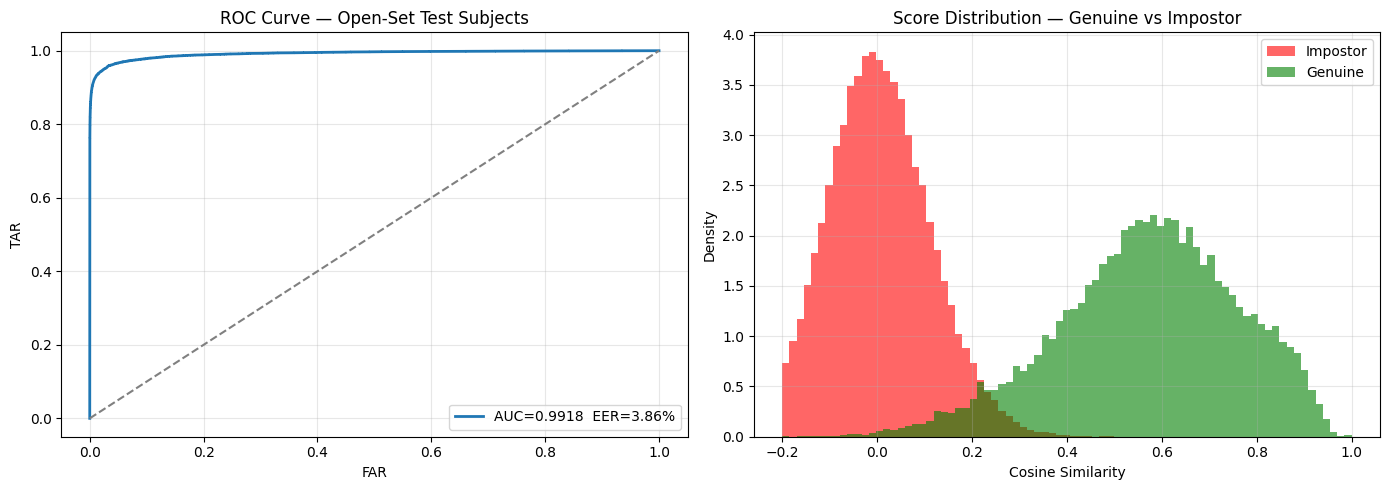

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(metrics["fpr"], metrics["tpr"], lw=2,
         label=f"AUC={metrics['auc']:.4f}  EER={metrics['eer']:.2f}%")
ax1.plot([0, 1], [0, 1], "--", color="gray")
ax1.set(xlabel="FAR", ylabel="TAR", title="ROC Curve — Open-Set Test Subjects")
ax1.legend(); ax1.grid(True, alpha=0.3)

gen_scores = metrics["scores"][metrics["is_genuine"] == 1]
imp_scores = metrics["scores"][metrics["is_genuine"] == 0]
bins = np.linspace(-0.2, 1.0, 80)
ax2.hist(imp_scores, bins=bins, alpha=0.6, label="Impostor", color="red",   density=True)
ax2.hist(gen_scores, bins=bins, alpha=0.6, label="Genuine",  color="green", density=True)
ax2.set(xlabel="Cosine Similarity", ylabel="Density",
        title="Score Distribution — Genuine vs Impostor")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "openset_evaluation.png"), dpi=150)
plt.show()

## t-SNE Visualization

Running t-SNE on 2000 embeddings with perplexity=30...


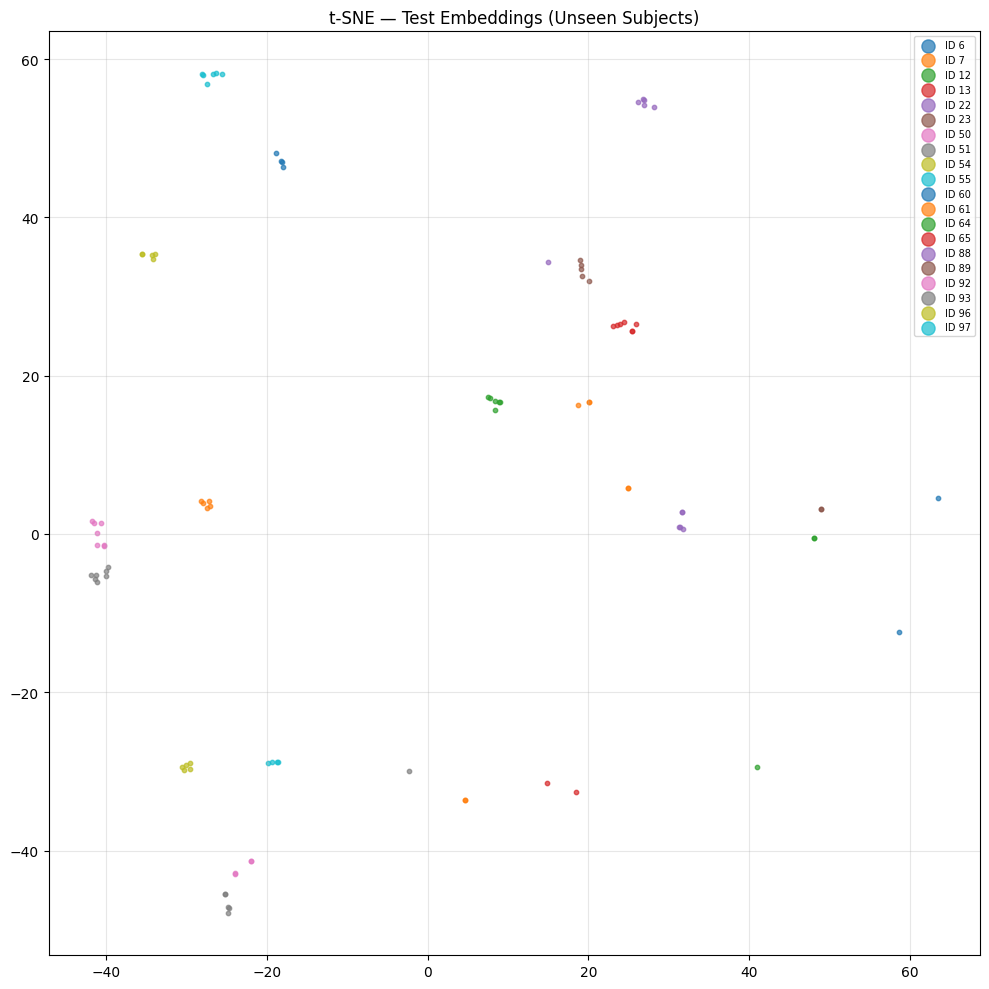

In [16]:
# Use a subset of test embeddings for t-SNE
N_TSNE = min(2000, len(test_embeds))
tsne_idx = np.random.default_rng(SEED).choice(len(test_embeds), N_TSNE, replace=False)
tsne_emb = test_embeds[tsne_idx]
tsne_lbl = test_labels_arr[tsne_idx]
perplexity = min(30, max(5, (N_TSNE - 1) // 3))

print(f"Running t-SNE on {N_TSNE} embeddings with perplexity={perplexity}...")
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=perplexity,
    max_iter=1000,
    init="pca",
    learning_rate="auto",
)
tsne_2d = tsne.fit_transform(tsne_emb)

unique_tsne_labels = np.unique(tsne_lbl)
n_colors = min(len(unique_tsne_labels), 20)

fig, ax = plt.subplots(figsize=(10, 10))
for i, lbl in enumerate(unique_tsne_labels[:n_colors]):
    mask = tsne_lbl == lbl
    ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], s=10, alpha=0.7, label=f"ID {lbl}")
if n_colors <= 20:
    ax.legend(markerscale=3, fontsize=7, loc="best")
ax.set_title("t-SNE — Test Embeddings (Unseen Subjects)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "tsne.png"), dpi=150)
plt.show()

## GradCAM++ Visualization

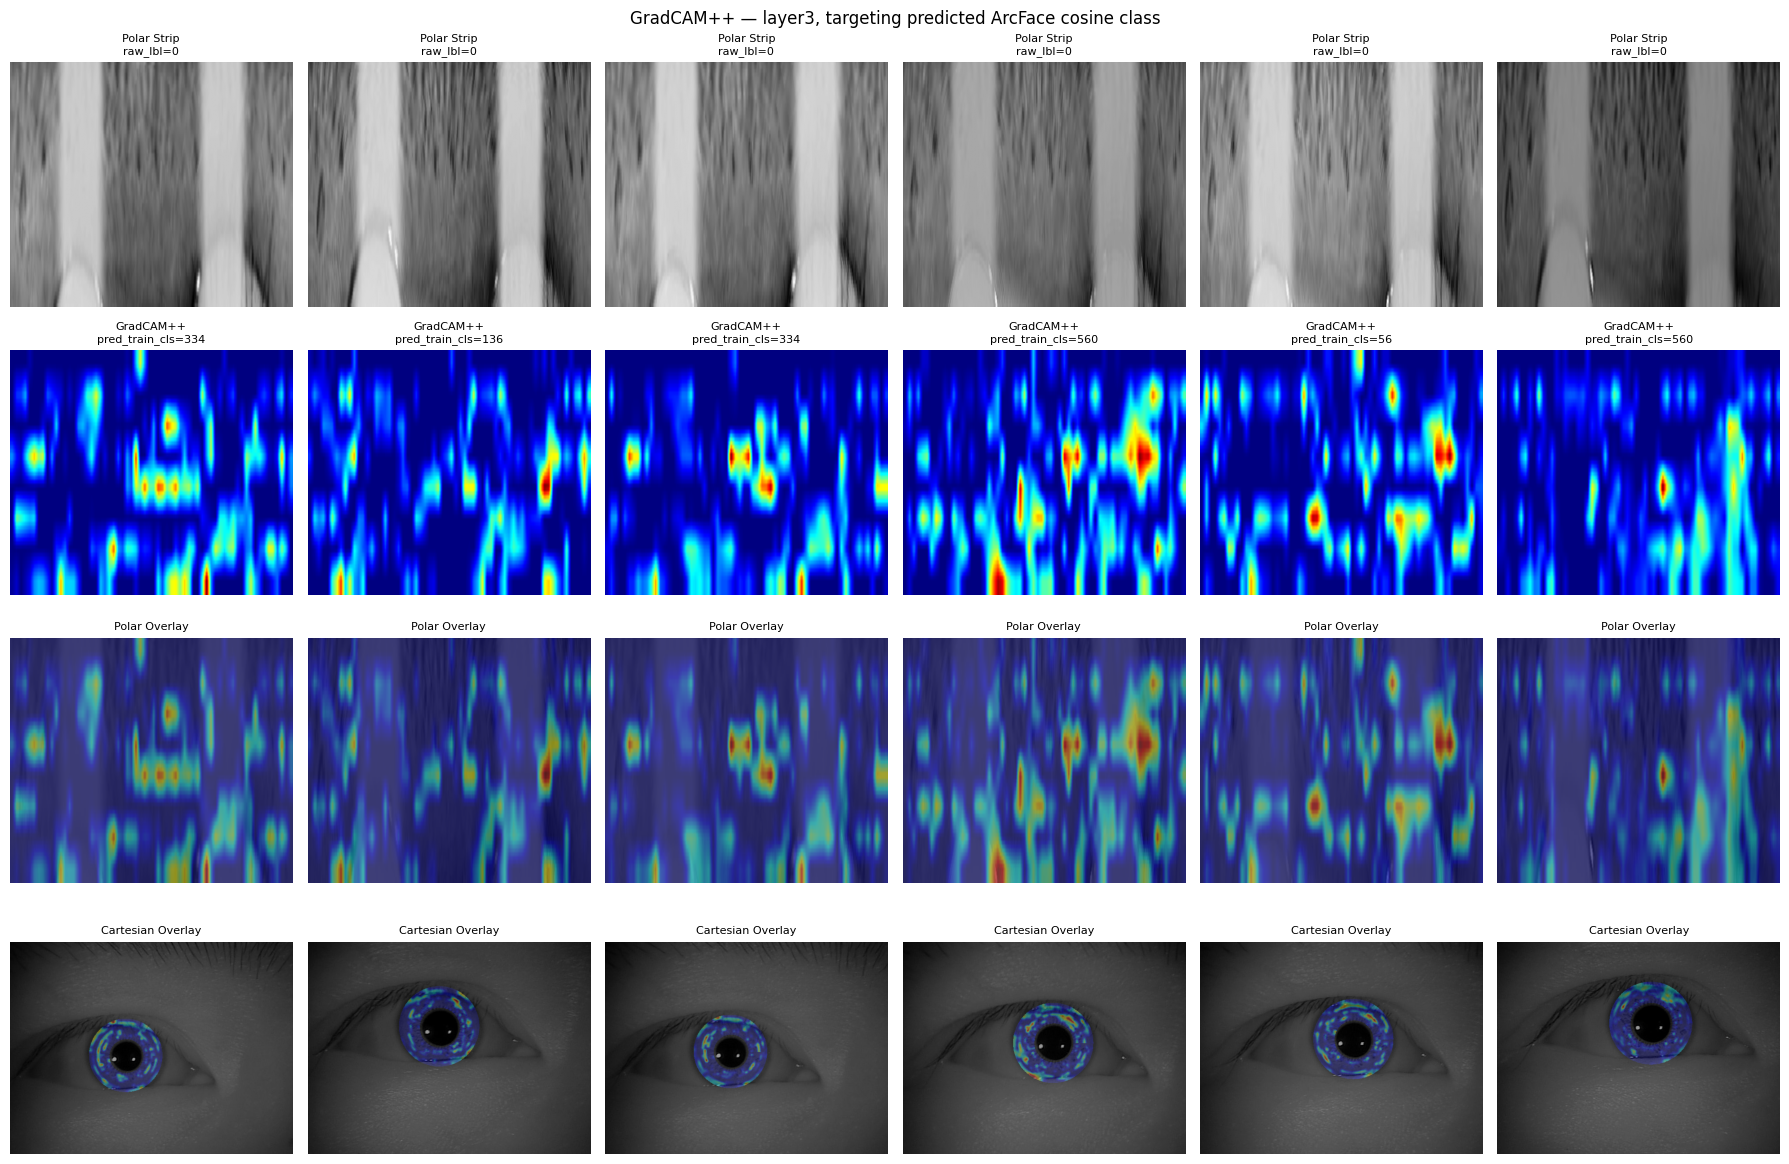

GradCAM saved: /kaggle/working/iris_model_v5/gradcam.png


In [17]:
class GradCAMWrapper(nn.Module):
    """Wrapper that returns ArcFace cosine logits for GradCAM targeting."""
    def __init__(self, backbone, arcface_head):
        super().__init__()
        self.backbone = backbone
        self.arcface_head = arcface_head

    def forward(self, x):
        emb, _, _ = self.backbone(x)
        return self.arcface_head.get_cosine(emb)


wrapped = GradCAMWrapper(base_model, arcface).to(DEVICE).eval()


def map_polar_to_cartesian(heatmap_color, orig_shape, pupil_xyr, iris_xyr):
    """Project a polar GradCAM heatmap back onto the original Cartesian eye image."""
    h, w = orig_shape
    px, py, pr = map(float, pupil_xyr)
    ix, iy, ir = map(float, iris_xyr)
    polar_h, polar_w = heatmap_color.shape[:2]

    theta = np.linspace(0, 2 * pi, polar_w, endpoint=False)
    px_circle = px + pr * np.cos(theta)
    py_circle = py + pr * np.sin(theta)
    ix_circle = ix + ir * np.cos(theta)
    iy_circle = iy + ir * np.sin(theta)
    radius = np.linspace(CONFIG["radial_inner"], CONFIG["radial_outer"], polar_h)[:, np.newaxis]

    x_coords = (1 - radius) * px_circle + radius * ix_circle
    y_coords = (1 - radius) * py_circle + radius * iy_circle

    cartesian = np.zeros((h, w, 3), dtype=np.uint8)
    for r_idx in range(polar_h - 1):
        for t_idx in range(polar_w):
            t_next = (t_idx + 1) % polar_w
            pts = np.array([
                [x_coords[r_idx, t_idx],     y_coords[r_idx, t_idx]],
                [x_coords[r_idx, t_next],    y_coords[r_idx, t_next]],
                [x_coords[r_idx + 1, t_next], y_coords[r_idx + 1, t_next]],
                [x_coords[r_idx + 1, t_idx],  y_coords[r_idx + 1, t_idx]],
            ], np.int32)
            cv2.fillConvexPoly(cartesian, pts, heatmap_color[r_idx, t_idx].tolist())
    return cartesian


def _load_cartesian_for_dataset_sample(ds, i):
    """Return original image and saved segmentation geometry for a cached dataset sample."""
    orig_path = ds.image_paths[i]
    orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    if orig_img is None:
        return None, None, None, orig_path

    meta = ds.meta[i] if hasattr(ds, "meta") and i < len(ds.meta) else {}
    pupil = meta.get("pupil") if isinstance(meta, dict) else None
    iris = meta.get("iris") if isinstance(meta, dict) else None

    # Fallback only if metadata is missing. Normally we reuse saved geometry so
    # GradCAM uses exactly the same segmentation as training/evaluation.
    if pupil is None:
        pupil = find_pupil_circle(orig_img)
    if iris is None and pupil is not None:
        iris = find_iris_circle(orig_img, pupil)
    return orig_img, pupil, iris, orig_path


# GradCAM is post-analysis only; make it non-blocking so ONNX export still runs.
try:
    from pytorch_grad_cam import GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

    base_model.eval(); arcface.eval(); wrapped.eval()
    cam_ds = val_ds if len(val_ds) > 0 else test_ds
    N_VIS = min(6, len(cam_ds))

    if N_VIS == 0:
        print("GradCAM skipped: no samples available.")
    else:
        # Use layer3 for GradCAM (8×64 for 64×512 input — better spatial resolution than layer4).
        target_layer = base_model.layer3[-1]
        fig, axes = plt.subplots(4, N_VIS, figsize=(3 * N_VIS, 12))
        if N_VIS == 1:
            axes = axes.reshape(4, 1)

        with GradCAMPlusPlus(model=wrapped, target_layers=[target_layer]) as cam:
            for i in range(N_VIS):
                t, lbl = cam_ds[i]
                inp = t.unsqueeze(0).to(DEVICE, non_blocking=True)

                with torch.no_grad():
                    pred = int(wrapped(inp).argmax(1).item())

                gcam = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred)])[0]

                # Original normalized polar strip -> display uint8.
                orig = t[0].detach().cpu().numpy()
                orig_disp = ((orig * CONFIG["norm_std"] + CONFIG["norm_mean"]) * 255).clip(0, 255).astype(np.uint8)

                heatmap_color = cv2.applyColorMap((gcam * 255).astype(np.uint8), cv2.COLORMAP_JET)
                heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
                heatmap_resized = cv2.resize(heatmap_color, (CONFIG["polar_width"], CONFIG["polar_height"]))

                orig_3ch = cv2.cvtColor(orig_disp, cv2.COLOR_GRAY2RGB)
                overlay = cv2.addWeighted(orig_3ch, 0.55, heatmap_resized, 0.45, 0)

                orig_img, pupil, iris, orig_path = _load_cartesian_for_dataset_sample(cam_ds, i)
                if orig_img is not None:
                    orig_img_3ch = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)
                    if pupil is not None and iris is not None:
                        cart_heatmap = map_polar_to_cartesian(heatmap_resized, orig_img.shape, pupil, iris)
                        cart_overlay = cv2.addWeighted(orig_img_3ch, 0.65, cart_heatmap, 0.35, 0)
                    else:
                        cart_overlay = orig_img_3ch
                else:
                    cart_overlay = np.zeros((CONFIG["polar_height"], CONFIG["polar_width"], 3), dtype=np.uint8)

                axes[0, i].imshow(orig_disp, cmap="gray", aspect="auto")
                axes[0, i].set_title(f"Polar Strip\nraw_lbl={lbl}", fontsize=8); axes[0, i].axis("off")

                axes[1, i].imshow(heatmap_resized, aspect="auto")
                axes[1, i].set_title(f"GradCAM++\npred_train_cls={pred}", fontsize=8); axes[1, i].axis("off")

                axes[2, i].imshow(overlay, aspect="auto")
                axes[2, i].set_title("Polar Overlay", fontsize=8); axes[2, i].axis("off")

                axes[3, i].imshow(cart_overlay)
                axes[3, i].set_title("Cartesian Overlay", fontsize=8); axes[3, i].axis("off")

        plt.suptitle("GradCAM++ — layer3, targeting predicted ArcFace cosine class", fontsize=12)
        plt.tight_layout()
        gradcam_path = os.path.join(CONFIG["save_dir"], "gradcam.png")
        plt.savefig(gradcam_path, dpi=150)
        plt.show()
        print(f"GradCAM saved: {gradcam_path}")

except Exception as e:
    import traceback
    print("GradCAM post-analysis failed, but this is non-critical. ONNX export can continue.")
    print(type(e).__name__, str(e))
    traceback.print_exc(limit=2)


## ONNX Export

In [18]:
import json


def _safe_torch_load(path, map_location=None):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


best_ckpt_path = os.path.join(CONFIG["save_dir"], "best_model.pth")
if "ckpt" not in globals() and os.path.exists(best_ckpt_path):
    ckpt = _safe_torch_load(best_ckpt_path, map_location=DEVICE)

# Export the best checkpoint if available. This makes the ONNX cell runnable even
# if the notebook was resumed from a saved model.
if "ckpt" in globals():
    base_model.load_state_dict(ckpt["model_state_dict"])
    if "arcface_state_dict" in ckpt:
        arcface.load_state_dict(ckpt["arcface_state_dict"])
    print(f"ONNX export using best checkpoint from epoch {ckpt.get('epoch', -1) + 1}")
else:
    ckpt = {}
    print("WARNING: best_model.pth not found/loaded; exporting current in-memory weights.")

base_model.eval(); arcface.eval()


class ONNXWrapper(nn.Module):
    """Export-safe wrapper — ONNX sees only the embedding output."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        emb, _, _ = self.backbone(x)
        return emb


export_model = ONNXWrapper(base_model).to(DEVICE).eval()
dummy = torch.randn(1, 1, CONFIG["polar_height"], CONFIG["polar_width"], device=DEVICE)
onnx_path = os.path.join(CONFIG["save_dir"], "iris_iresnet50_msff_embedding.onnx")


def _torch_onnx_export_compat(model, dummy_input, path, opset_version):
    common_kwargs = dict(
        args=dummy_input,
        f=path,
        export_params=True,
        opset_version=opset_version,
        do_constant_folding=True,
        input_names=["iris_polar"],
        output_names=["embedding"],
        dynamic_axes={
            "iris_polar": {0: "batch_size"},
            "embedding": {0: "batch_size"},
        },
    )
    try:
        torch.onnx.export(model, **common_kwargs, dynamo=False)
    except TypeError as e:
        # Older PyTorch versions do not support the dynamo argument.
        if "dynamo" in str(e):
            torch.onnx.export(model, **common_kwargs)
        else:
            raise


export_errors = []
exported_opset = None
for opset in [17, 13, 12]:
    try:
        _torch_onnx_export_compat(export_model, dummy, onnx_path, opset_version=opset)
        exported_opset = opset
        break
    except Exception as e:
        export_errors.append((opset, repr(e)))
        print(f"ONNX export failed at opset {opset}: {e}")

if exported_opset is None:
    raise RuntimeError(f"ONNX export failed for opsets 17/13/12: {export_errors}")

print(f"ONNX embedding model saved: {onnx_path}")
print(f"ONNX opset: {exported_opset}; size: {os.path.getsize(onnx_path)/1024/1024:.1f} MB")

try:
    import onnx
    onnx.checker.check_model(onnx.load(onnx_path))
    print("ONNX graph verified")
except Exception as e:
    print(f"ONNX checker warning: {type(e).__name__}: {e}")

# Optional quick PyTorch-vs-ONNXRuntime parity check.
try:
    import onnxruntime as ort
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if DEVICE.type == "cuda" else ["CPUExecutionProvider"]
    sess = ort.InferenceSession(onnx_path, providers=providers)
    dummy_np = dummy.detach().cpu().numpy().astype(np.float32)
    onnx_out = sess.run(None, {"iris_polar": dummy_np})[0]
    with torch.no_grad():
        pt_out = export_model(dummy).detach().cpu().numpy()
    max_abs_diff = float(np.max(np.abs(onnx_out - pt_out)))
    print(f"ONNXRuntime parity max_abs_diff: {max_abs_diff:.6g}")
except ImportError:
    print("onnxruntime not installed; parity check skipped.")
except Exception as e:
    print(f"ONNXRuntime parity warning: {type(e).__name__}: {e}")

DEPLOYMENT_NOTE = f"""
# Deployment pipeline note

The exported ONNX file is the embedding network only:

    normalized polar iris strip ({CONFIG['polar_height']}x{CONFIG['polar_width']}) -> 512-D L2-normalized embedding

It does not include the full iris-recognition stack. A real deployment must still run:

1. camera/NIR frame acquisition;
2. grayscale preprocessing;
3. pupil localization;
4. limbus/iris localization;
5. Daugman rubber-sheet normalization;
6. radial crop and optional angular mask;
7. normalization using mean={CONFIG['norm_mean']} and std={CONFIG['norm_std']};
8. ONNX/TensorRT embedding inference;
9. cosine similarity against enrolled templates;
10. decision using the open-validation deployment threshold saved in the checkpoint.

Open-validation EER threshold from selected checkpoint: {ckpt.get('val_threshold', float('nan')):.6f}
Open-validation target-FAR deployment threshold: {ckpt.get('val_threshold_far', float('nan')):.6f}
Target FAR used for deployment threshold: {ckpt.get('target_far', CONFIG.get('target_far', float('nan')))}
ONNX opset exported: {exported_opset}

For Jetson/TensorRT, test ONNX Runtime or TensorRT compatibility. If opset 17 is unsupported on the target stack, this cell automatically falls back to opset 13 or 12.
"""
with open(os.path.join(CONFIG["save_dir"], "deployment_pipeline_note.md"), "w") as f:
    f.write(DEPLOYMENT_NOTE)

metadata = {
    "onnx_path": onnx_path,
    "opset": exported_opset,
    "polar_height": CONFIG["polar_height"],
    "polar_width": CONFIG["polar_width"],
    "norm_mean": CONFIG["norm_mean"],
    "norm_std": CONFIG["norm_std"],
    "radial_inner": CONFIG["radial_inner"],
    "radial_outer": CONFIG["radial_outer"],
    "use_angular_mask": CONFIG.get("use_angular_mask", True),
    "angular_keep_frac": CONFIG.get("angular_keep_frac", None),
    "angular_mask_floor": CONFIG.get("angular_mask_floor", None),
    "angular_soft_edge": CONFIG.get("angular_soft_edge", None),
    "val_threshold_eer": ckpt.get("val_threshold", None),
    "val_threshold_target_far": ckpt.get("val_threshold_far", None),
    "target_far": ckpt.get("target_far", CONFIG.get("target_far", None)),
}
with open(os.path.join(CONFIG["save_dir"], "deployment_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Deployment note written: deployment_pipeline_note.md")
print("Deployment metadata written: deployment_metadata.json")


ONNX export using best checkpoint from epoch 36


/tmp/ipykernel_24/2361163621.py:60: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, **common_kwargs, dynamo=False)


ONNX embedding model saved: /kaggle/working/iris_model_v5/iris_iresnet50_msff_embedding.onnx
ONNX opset: 17; size: 167.6 MB
ONNX graph verified
onnxruntime not installed; parity check skipped.
Deployment note written: deployment_pipeline_note.md
Deployment metadata written: deployment_metadata.json


## Unit Tests

In [19]:
import traceback

PASS = "  PASS"
FAIL = "  FAIL"

def run_test(name, fn):
    try:
        fn()
        print(f"{PASS}  {name}")
    except Exception:
        print(f"{FAIL}  {name}")
        traceback.print_exc()

def test_subject_exclusive_splits():
    assert train_subjects.isdisjoint(val_subjects)
    assert train_subjects.isdisjoint(test_subjects)
    assert val_subjects.isdisjoint(test_subjects)

def test_no_zero_failed_samples_kept():
    for ds in [train_ds, val_ds, test_ds]:
        assert len(ds.cache) == len(ds.labels) == len(ds.image_paths)
        assert all(a is not None and a.any() for a in ds.cache[:min(20, len(ds.cache))])

def test_polar_output_shape():
    for ds in [train_ds, val_ds, test_ds]:
        assert ds.cache[0].shape == (CONFIG["polar_height"], CONFIG["polar_width"])

def test_normalization_consistency():
    tensor, _ = val_ds[0]
    mean_val = tensor.mean().item()
    assert abs(mean_val) < 1.5, f"Tensor mean {mean_val:.3f}"

def test_arcface_label_mapping():
    assert len(train_label_names) == NUM_CLASSES
    assert arcface.weight.shape[0] == NUM_CLASSES
    assert all(0 <= l < NUM_CLASSES for l in train_ds.labels)

def test_checkpoint_label_names_are_remapped():
    assert ckpt["label_names"] == train_label_names
    assert ckpt["old_class_ids"] == train_old_class_ids

def test_arcface_logit_ordering():
    arcface.eval()
    dummy_emb = F.normalize(torch.randn(4, 512).to(DEVICE), dim=1)
    dummy_lbl = torch.zeros(4, dtype=torch.long).to(DEVICE)
    arcface_logits = arcface(dummy_emb, dummy_lbl)
    cosine_logits  = arcface.get_cosine(dummy_emb)
    gt_arcface = arcface_logits[:, 0] / arcface.s
    gt_cosine  = cosine_logits[:, 0]
    assert (gt_arcface <= gt_cosine + 1e-4).all().item()

def test_embedding_is_unit_norm():
    base_model.eval()
    dummy = torch.randn(4, 1, CONFIG["polar_height"], CONFIG["polar_width"]).to(DEVICE)
    with torch.no_grad():
        emb, _, _ = base_model(dummy)
    norms = torch.norm(emb, dim=1)
    assert (norms - 1.0).abs().max().item() < 1e-5

def test_gradcam_output_shape():
    dummy = torch.randn(1, 1, CONFIG["polar_height"], CONFIG["polar_width"]).to(DEVICE)
    with torch.no_grad():
        out = wrapped(dummy)
    assert out.shape == (1, NUM_CLASSES)

def test_onnx_batch1_and_parity():
    try:
        import onnxruntime as ort
    except ImportError:
        print("    (onnxruntime not installed → skipping)")
        return
    sess  = ort.InferenceSession(onnx_path)
    dummy_np = np.random.randn(1, 1, CONFIG["polar_height"], CONFIG["polar_width"]).astype(np.float32)
    out_onnx = sess.run(None, {"iris_polar": dummy_np})[0]
    assert out_onnx.shape == (1, 512)
    assert abs(np.linalg.norm(out_onnx[0]) - 1.0) < 1e-5
    with torch.no_grad():
        out_pt = export_model(torch.from_numpy(dummy_np).to(DEVICE)).cpu().numpy()
    np.testing.assert_allclose(out_onnx, out_pt, rtol=1e-3, atol=1e-4)

def test_eer_sane():
    assert 0 <= metrics["eer"] <= 50
    assert 0.5 <= metrics["auc"] <= 1.0
    assert "threshold" in metrics
    assert "threshold_far" in metrics
    assert np.isfinite(metrics["threshold_far"])

print("Running unit tests...\n")
run_test("T1:  Subject-exclusive train/val/test splits", test_subject_exclusive_splits)
run_test("T2:  Failed segmentation samples are not kept as zeros", test_no_zero_failed_samples_kept)
run_test("T3:  Polar output shape correct", test_polar_output_shape)
run_test("T4:  Tensor normalization in valid range", test_normalization_consistency)
run_test("T5:  ArcFace labels are correctly remapped", test_arcface_label_mapping)
run_test("T6:  Checkpoint label_names match remapped training classes", test_checkpoint_label_names_are_remapped)
run_test("T7:  ArcFace margin suppresses GT logit", test_arcface_logit_ordering)
run_test("T8:  Embeddings are L2-normalized", test_embedding_is_unit_norm)
run_test("T9:  GradCAM wrapper returns class logits", test_gradcam_output_shape)
run_test("T10: ONNX batch=1 inference and PyTorch parity", test_onnx_batch1_and_parity)
run_test("T11: EER/AUC in sane range", test_eer_sane)

Running unit tests...

  PASS  T1:  Subject-exclusive train/val/test splits
  PASS  T2:  Failed segmentation samples are not kept as zeros
  PASS  T3:  Polar output shape correct
  PASS  T4:  Tensor normalization in valid range
  PASS  T5:  ArcFace labels are correctly remapped
  PASS  T6:  Checkpoint label_names match remapped training classes
  PASS  T7:  ArcFace margin suppresses GT logit
  PASS  T8:  Embeddings are L2-normalized
  PASS  T9:  GradCAM wrapper returns class logits
    (onnxruntime not installed → skipping)
  PASS  T10: ONNX batch=1 inference and PyTorch parity
  PASS  T11: EER/AUC in sane range


## Done

v5 notebook fixes applied:
- failed segmentations are filtered out and reported as failure-to-enroll/acquire;
- validation is subject-exclusive and used for open-set EER checkpoint selection;
- checkpoint label names are the remapped ArcFace training class names;
- t-SNE uses `max_iter` for current scikit-learn;
- evaluation reports bootstrap confidence intervals and validation-threshold test performance;
- ONNX export is explicitly documented as embedding-only;
- the fixed angular/wing mask is documented as a risky ablation rather than a demographic assumption.


## v6 speed / calibration patch notes

This regenerated version keeps the improved iris crop but adds:
- conditional dependency install to avoid wasting startup time and causing CUDA package conflicts;
- larger default batch size (`128`) for T4x2/4090/A100 style GPUs;
- TF32 enabled on Ampere/Ada/Hopper GPUs;
- faster non-blocking GPU transfers and `zero_grad(set_to_none=True)`;
- randomized angular masks are precomputed in a small mask bank instead of rebuilt per sample;
- open-validation can run every 2 epochs after early training;
- early stopping ignores tiny EER noise improvements below `early_stop_min_delta`;
- EER threshold and target-FAR deployment threshold are now saved separately;
- a second checkpoint is saved for best `TAR@0.1%FAR`.

For a final thesis run, set `bootstrap_resamples` back to `1000` and optionally set `epochs` to `40`.
